Patch foraging + FIP analyses, version 6. Updating functions to calculate baseline of PSTHs from specified pre-windows.

In [2]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

from os import PathLike
import os

from aind_vr_foraging_analysis.utils.parsing import parse, data_access
import aind_vr_foraging_analysis.utils.plotting as plotting

# Plotting libraries
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
import pytz
from datetime import datetime
sns.set_context('talk')

import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='yellow'
odor_list_color = [color1, color2, color3, color4]

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
    'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
    'PatchB': '#d95f02','PatchA': '#7570b3', 
    'PatchC': '#1b9e77',
    'Alpha-pinene': '#1b9e77', 
    'Methyl Butyrate': '#7570b3', 
    'Amyl Acetate': '#d95f02', 
    'Fenchone': '#7570b3', 
    'Dipropyl sulfide': '#7570b3',
    'Dypropil sulfide': '#7570b3',
    'Hexanal': '#1b9e77',
    'Pentyl acetate': '#d95f02',
    'S': color1,
    'D': color2,
    'N': color3,   
    'Do': color1,
    'None': color4, 
    'odor_0': color3,
    'odor_60': color2,
    'odor_90': color1,
    'odor_fast': '#d95f02',
    'odor_slow': '#1b9e77',
    'A': color1,
    'B': color2,
    'C': color3,
    'OdorA': color1,
    'OdorB': color2,
    'OdorC': color3,
    }

label_dict = {
    **{"InterSite": '#808080', "InterPatch": '#b3b3b3'}, 
    **color_dict_label
}

pdf_path = r'C:\Users\jason.lee\OneDrive - Allen Institute\Documents\patch_foraging\sessions'
base_path = r'\\allen\aind\stage\vr-foraging\data'
foraging_figures = r'C:\Users\jason.lee\OneDrive - Allen Institute\Documents\patch_foraging'


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#Session picker
from pathlib import Path

#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-19T234013Z")
session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-17T232028Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-15T231441Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-12T231442Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-11T194307Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-10T235940Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-09T191007Z")
#session_path = Path(r"Y:\vr-foraging\data\788731\788731_2025-12-08T225800Z")

#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-20T002820Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-18T000750Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-16T000745Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-13T000905Z")
#session_path = Path(r"Y:\vr-foraging\data\810351\810351_2025-12-11T184700Z")

# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-20T235758Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-24T233544Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-25T232029Z")
# session_path = Path(r"Y:\vr-foraging\data\804430\804430_2025-11-26T234133Z")

# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-22T000144Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-25T004352Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-26T001812Z")
# session_path = Path(r"Y:\vr-foraging\data\804434\804434_2025-11-27T003255Z")

subject_ID = int(session_path.parts[session_path.parts.index("data") + 1])
print(subject_ID)

session_date = session_path.name.split("_", 1)[1].split("T", 1)[0]
print(session_date)  # 2025-12-15


##if you know the exact name
# fip_dir = session_dir / "fib" / "fip_2025-12-03T164904"

# or, if you just know it's fip_***
fib_dir = session_path / "fib"
FIP_Dir = next(fib_dir.glob("fip_*"))  # gets the first folder matching fip_*
FIP_Dir = str(FIP_Dir)
print(FIP_Dir)

788731
2025-12-17
Y:\vr-foraging\data\788731\788731_2025-12-17T232028Z\fib\fip_2025-12-17T152441


In [4]:
def stage_to_numeric(stage_str):
    # Split the stage string
    parts = stage_str.split('_')

    # Find parts with "distance" and "stop"
    stage_part = next((p for p in parts if 'stage' in p), '')
    distance_part = next((p for p in parts if 'distance' in p), '')
    stop_part = next((p for p in parts if 'stop' in p), '')

    # Extract suffix letters
    distance_letter = distance_part.replace('distance', '') if 'distance' in distance_part else ''
    stop_letter = stop_part.replace('stop', '') if 'stop' in stop_part else ''
    stage_letter = stop_part.replace('stage', '') if 'stage' in stage_part else ''

    # Define letter-to-value mapping
    letter_value = {'B': 2, 'C': 3, 'D': 5, 'E':7}

    # Get values
    d_val = letter_value.get(distance_letter, 1)
    s_val = letter_value.get(stop_letter, 1)

    # If both are D, return 5
    if distance_letter == 'D' and stop_letter == 'D':
        return 6
    elif distance_letter == 'C' and stop_letter == 'C':
        return 4
    elif stage_letter == 'B':
        return 8
    else:
        return max(d_val, s_val)

In [5]:
# Function to assign codes
def get_condition_code(text):
    if 'delayed' in text:
        return 'D'
    elif 'single' in text:
        return 'S'
    elif 'no_reward' in text or 'noreward' in text:
        return 'N'
    elif 'double' in text:
        return 'Do'
    else:
        return text

In [6]:
class MetricsVrForaging():
    def __init__(self, session_path: PathLike):
        self.session_path = session_path
        self.active_site, self.stream_data, self.data = data_access.load_session(
        session_path
        )
        
        
        self.reward_sites = self.active_site.loc[self.active_site['label'] == 'OdorSite']

        utc = pytz.UTC
        local_tz = pytz.timezone("America/Los_Angeles")

        utc_str = self.data['config'].streams.session_input.data['date']
        utc_dt = datetime.fromisoformat(utc_str)        # full timestamp
        local_dt = utc_dt.replace(tzinfo=utc).astimezone(local_tz)
        self.session = str(local_dt.date())  
        self.mouse = int(self.data['config'].streams.session_input.data['subject'])
        self.stage = self.data['config'].streams.tasklogic_input.data['stage_name']
        self.rig_name = self.data['config'].streams.rig_input.data['rig_name']
        self.experimenter = self.data['config'].streams.session_input.data['experimenter'][0]
        self.updaters = self.data['config'].streams.tasklogic_input.data['task_parameters']['updaters']

        print(self.rig_name)
        print(self.stage)
        print(self.experimenter)
        
        if self.stage == 'thermistor screening':
            return
        
        self.df = self.retrieve_metrics()

    def retrieve_metrics(self) -> pd.DataFrame:
        reward_sites = self.reward_sites
        active_site = self.active_site
        data = self.data

        df = pd.DataFrame()
        # Summary of different relevants aspects -------------------------------------------------

        unrewarded_stops = reward_sites.loc[reward_sites.is_reward==0]['reward_amount'].count()
        rewarded_stops = reward_sites.loc[reward_sites.is_reward==1]['reward_amount'].count()
        water_collected = reward_sites.loc[(reward_sites['is_reward']==1)]['reward_amount'].sum()
        total_stops = reward_sites.loc[(reward_sites['is_choice']==True)]['reward_amount'].count()

        print('Total sites: ' ,len(reward_sites), ' | ', 'Total rewarded stops: ',rewarded_stops, '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            'Total unrewarded stops: ',unrewarded_stops,'(',  np.round((unrewarded_stops/total_stops)*100,2),'%) | ','Water consumed: ', water_collected, 'ul')

        print('Total travelled m: ', np.round(active_site.start_position.max()/100,2), ', current position (cm): ', data['operation_control'].streams.CurrentPosition.data.max()[0]
        )

        for odor_label in reward_sites.odor_label.unique():
            values = reward_sites.loc[(reward_sites['odor_label']==odor_label)&(reward_sites['is_reward']==1)]['reward_amount'].sum()
            print(f'{odor_label} {values} ul')
            
        df.at[0,'odor_sites_travelled'] = int(len(reward_sites))
        df.at[0,'distance_m'] = data['operation_control'].streams.CurrentPosition.data.max()[0]/100
        df.at[0,'water_collected_ul'] = water_collected
        df.at[0,'rewarded_stops'] = int(rewarded_stops)
        df.at[0,'total_stops'] = int(total_stops)
        df.at[0,'session_duration_min'] = (reward_sites.index[-1] - reward_sites.index[0])/60
        df.at[0, 'total_patches_visited'] = reward_sites.loc[reward_sites['site_number'] >= 1].patch_number.nunique()
        return df

    def retrieve_updater_values(self):
        # Initialize a pointer for the data values
        data_pointer = 0
        
        reward_sites = self.reward_sites
        data = self.data
        df = self.df
        
        # Helper function to safely extract stream data
        def get_stream_data(data, key):
            try:
                stream = data['updater_events'].streams[key].data['data']
                stream.reset_index(drop=True, inplace=True)
                return stream
            except (KeyError, AttributeError):
                return None

        # Load updater data safely
        stop_duration = get_stream_data(data, 'UpdaterStopDurationOffset')
        delay = get_stream_data(data, 'UpdaterRewardDelayOffset')
        velocity_threshold = get_stream_data(data, 'UpdaterStopVelocityThreshold')

        # Create new columns in reward_sites with default values
        reward_sites['delay_s'] = np.nan
        reward_sites['velocity_threshold_cms'] = np.nan
        reward_sites['stop_duration_s'] = np.nan

        data_pointer = 0
        try:
            for index, row in reward_sites.iterrows():
                if row['is_reward'] == 1:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
                    data_pointer += 1
                else:
                    if delay is not None and len(delay) > data_pointer:
                        reward_sites.at[index, 'delay_s'] = delay[data_pointer]
                    if velocity_threshold is not None and len(velocity_threshold) > data_pointer:
                        reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold[data_pointer]
                    if stop_duration is not None and len(stop_duration) > data_pointer:
                        reward_sites.at[index, 'stop_duration_s'] = stop_duration[data_pointer]
        except IndexError:
            if delay is not None:
                reward_sites.at[index, 'delay_s'] = delay.max()
            if velocity_threshold is not None:
                reward_sites.at[index, 'velocity_threshold_cms'] = velocity_threshold.max()
            if stop_duration is not None:
                reward_sites.at[index, 'stop_duration_s'] = stop_duration.max()

        # Summary of the training metrics
        reward_sites['odor_sites'] = np.arange(1, len(reward_sites) + 1)

        # Safely update df only if values exist
        if delay is not None:
            df.at[0, 'start_delay'] = reward_sites['delay_s'].min()
            df.at[0, 'end_delay'] = reward_sites['delay_s'].max()
            df.at[0, 'sites_to_max_delay'] = reward_sites[reward_sites['delay_s'] == reward_sites['delay_s'].max()].iloc[0]['odor_sites']

        if stop_duration is not None:
            df.at[0, 'start_stop_duration'] = reward_sites['stop_duration_s'].min()
            df.at[0, 'end_stop_duration'] = reward_sites['stop_duration_s'].max()
            df.at[0, 'sites_to_max_stop_duration'] = reward_sites[reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()].iloc[0]['odor_sites']
            df.at[0, 'rewarded_sites_in_max_stop'] = int(reward_sites[(reward_sites['stop_duration_s'] == reward_sites['stop_duration_s'].max()) & (reward_sites.is_choice == 1)]['odor_sites'].nunique())

        if velocity_threshold is not None:
            df.at[0, 'start_velocity_threshold'] = reward_sites['velocity_threshold_cms'].min()
            df.at[0, 'end_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'target_max_velocity_threshold'] = reward_sites['velocity_threshold_cms'].max()
            df.at[0, 'sites_to_min_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].min()].iloc[0]['odor_sites']
            df.at[0, 'sites_to_max_velocity'] = reward_sites[reward_sites['velocity_threshold_cms'] == reward_sites['velocity_threshold_cms'].max()].iloc[0]['odor_sites']        
        
        self.reward_sites = reward_sites
        self.df = df

    def get_metrics(self):
        return self.df

    def get_reward_sites(self):
        return self.reward_sites
    
    def get_mouse_and_session(self):
        return self.mouse, self.session
    
    def run_pdf_summary(self):
        color1='#d95f02'
        color2='#1b9e77'
        color3='#7570b3'
        color4='#e7298a'

        color_dict_label = {'InterSite': '#808080',
            'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
            'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
            'PatchB': '#d95f02','PatchA': '#7570b3', 
            'PatchC': '#1b9e77',
            'Alpha-pinene': '#1b9e77', 
            'Methyl Butyrate': '#7570b3', 
            'Amyl Acetate': '#d95f02', 
            'Fenchone': '#7570b3', 
            'Dipropyl sulfide': '#7570b3',
            'Dypropil sulfide': '#7570b3',
            'Hexanal': '#1b9e77',
            'Pentyl acetate': '#d95f02',
            'S': color1,
            'D': color2,
            'N': color3,   
            'Do': color1,
            'None': color4, 
            'odor_0': color3,
            'odor_60': color2,
            'odor_90': color1,
            'odor_fast': '#d95f02',
            'odor_slow': '#1b9e77',
            'A': color1,
            'B': color2,
            'C': color3,
            'OdorA': color1,
            'OdorB': color2,
            'OdorC': color3,
            }
        
        odor_sites = self.reward_sites.copy()
        encoder_data = self.stream_data.encoder_data
        active_site = self.active_site.copy()
        
        active_site['mouse'] = self.mouse
        active_site['session'] = self.session
        
        # Apply function
        active_site['long_patch_label'] = active_site['patch_label']
        active_site['patch_label'] = active_site['patch_label'].apply(get_condition_code)
        
        # odor_sites['odor_label'] = odor_sites['odor_label'].str.replace(' ', '_')
        
        # Remove segments where the mouse was disengaged
        last_engaged_patch = odor_sites['patch_number'][odor_sites['skipped_count'] >= 10].min()
        if pd.isna(last_engaged_patch):
            last_engaged_patch = odor_sites['patch_number'].max()
            
        odor_sites['engaged'] = odor_sites['patch_number'] <= last_engaged_patch  
    
        try:
            odor_sites['block'] = odor_sites['patch_label'].str.extract(r'set(\d+)').astype(int)
        except ValueError: 
            odor_sites['block'] = 0

        # Apply function
        odor_sites['long_patch_label'] = odor_sites['patch_label']
        odor_sites['patch_label'] = odor_sites['patch_label'].apply(get_condition_code)
        
        trial_summary = plotting.trial_collection(odor_sites[['is_choice', 'site_number', 'odor_label', 'depleted', 'odor_sites', 'is_reward','reward_probability','reward_amount','reward_available']], 
                                                  encoder_data, 
                                                  window=(-1,3)
                                                )
    
        # Save each figure to a separate page in the PDF
        pdf_filename = f'{self.mouse}_{self.session}_summary.pdf'
        with PdfPages(pdf_path+"\\"+pdf_filename) as pdf:
            text1 = ('Mouse: ' + str(self.mouse) 
            + '\nSession: ' + str(self.session) 
            + '\nRig: ' + str(self.rig_name) 
            + '\nStage: ' + str(self.stage)
            + '\nTotal sites travelled: '  + str(self.df.odor_sites_travelled.iloc[0]) 
            + '\nTotal choices: '  + str(self.df.total_stops.iloc[0]) 
            + '\nTotal rewarded stops: ' + str(self.df.rewarded_stops.iloc[0]) + ' (' +str(np.round((self.df.rewarded_stops.iloc[0]/self.df.total_stops.iloc[0])*100,2)) + '%) \n' 
            + 'Water consumed: ' +  str(np.round(self.df.water_collected_ul.iloc[0], 2)) + 'ul\n' 
            + 'Session duration: ' + str(np.round(self.df.session_duration_min.iloc[0],2)) + 'min\n' 
            + 'Total travelled m: ' + str(np.round(active_site.start_position.max()/100,2))
            )
            
            # '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
            text_to_figure = text1
            # if self.stage[:7] == 'shaping':
            #     text2 = '\nTotal sites travelled: ' + str(self.df.odor_sites_travelled.iloc[0]) + '\nRewarded stops in max stop duration: ' + str(self.df.rewarded_sites_in_max_stop.iloc[0]) + '\nTotal patches visited: ' + str(self.df.total_patches_visited.iloc[0])
            #     text_to_figure = text1 + text2
            
            # Create a figure
            fig, ax = plt.subplots(figsize=(8.5, 11))  # Standard letter size
            ax.text(0.1, 0.9, text_to_figure, ha='left', va='center', fontsize=12)
            ax.axis('off')  # Hide the axes
            pdf.savefig(fig)
            plt.close(fig)
            
            # plotting.raster_with_velocity(active_site, stream_data, color_dict_label=color_dict_label, save=pdf)
            plotting.segmented_raster_vertical(odor_sites, 
                                            save=pdf, 
                                            color_dict_label=color_dict_label)
            plotting.raster_with_velocity(active_site, self.stream_data, color_dict_label=color_dict_label, save=pdf)
        
            plotting.summary_withinsession_values(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_efficient(trial_summary, self.mouse, self.session,  save=pdf)
            plotting.preward_estimates(odor_sites, 
                                    color_dict_label = color_dict_label, 
                                    save=pdf)
            plotting.speed_traces_value(trial_summary, self.mouse, self.session, condition = 'reward_probability', save=pdf) 
            plotting.velocity_traces_odor_entry(trial_summary, max_range = trial_summary.speed.max(), color_dict_label=color_dict_label, save=pdf)

            plotting.length_distributions(self.active_site, self.data, delay=True, save=pdf)
            if len(self.updaters):
                plotting.update_values(self.reward_sites, save=pdf)
            
        return pdf_filename


In [7]:
### Load Patch Foraging Data
all_epochs, stream_data, data = data_access.load_session(session_path)
all_epochs['patch_label'] = all_epochs['patch_label'].apply(get_condition_code)
# all epochs gives you a trial-based table segmented by interpatch, intersite or odorsite. Stream_data gives access to continuous data parsed for interpretability. 

pd.set_option('display.max_columns',None)
all_epochs

Reward functions from software events


,label,start_position,length,friction,patch_number,patch_label,odor_label,site_number,stop_time,choice_cue_time,reward_onset_time,succesful_wait_time,is_choice,is_reward,reward_amount,reward_probability,reward_available,odor_sites,collected,depleted,last_visit,last_site,cumulative_rewards,consecutive_rewards,cumulative_failures,consecutive_failures,after_choice_cumulative_rewards,duration_epoch,patch_onset,time_since_entry,exit_epoch,skipped_count
start_time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2.086142e+06,InterPatch,29.901121,249.205106,0.0,0,odor_90,Pentyl acetate,NaN,2.086148e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664000,2.086148e+06,-6.664000,0.000000,NaN
2.086148e+06,InterSite,279.106227,37.067126,0.0,0,odor_90,Pentyl acetate,NaN,2.086151e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.325984,2.086148e+06,0.000000,2.325984,NaN
2.086151e+06,OdorSite,316.173353,50.000000,0.0,0,odor_90,Pentyl acetate,0.0,2.086155e+06,2.086152e+06,2.086152e+06,2.086152e+06,True,True,5.0,0.900000,9999.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.506016,2.086148e+06,2.325984,6.832000,0.0
2.086155e+06,InterSite,366.173353,24.423370,0.0,0,odor_90,Pentyl acetate,NaN,2.086156e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.868000,2.086148e+06,6.832000,7.700000,NaN
2.086156e+06,OdorSite,390.596723,50.000000,0.0,0,odor_90,Pentyl acetate,1.0,2.086161e+06,2.086157e+06,2.086157e+06,2.086157e+06,True,True,5.0,0.791551,9999.0,1.0,5.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,5.029984,2.086148e+06,7.700000,12.729984,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2.088521e+06,InterPatch,57204.554688,224.258591,0.0,70,odor_60,Hexanal,NaN,2.088527e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.056000,2.088527e+06,-6.056000,0.000000,NaN
2.088527e+06,InterSite,57428.813278,26.323706,0.0,70,odor_60,Hexanal,NaN,2.088528e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.702016,2.088527e+06,0.000000,0.702016,NaN
2.088528e+06,OdorSite,57455.136984,50.000000,0.0,70,odor_60,Hexanal,0.0,2.088529e+06,NaN,NaN,NaN,False,False,5.0,0.600000,9999.0,374.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.321984,2.088527e+06,0.702016,2.024000,2.0


In [ ]:
parsed_session = MetricsVrForaging(session_path)
parsed_session.get_reward_sites().columns

In [11]:
### Load FIP data

# FIP_Dir = r'\\allen\aind\stage\vr-foraging\data\810351\810351_2025-12-04T004844Z\fib\fip_2025-12-03T164904'
# subjectID = "810351"

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import csv
import glob
import re
from scipy.optimize import curve_fit
import json
import pandas as pd
from scipy.stats import sem

import PreprocessingFunctions_v2 as pf

# for visualization
Roi2Vis = [0,1]    

# params for pre-processing
nFrame2cut = 100  # crop initial n frames
sampling_rate = 20  # individual channel (not total)
kernelSize = 1  # median filter
degree = 4  # polyfit
b_percentile = 0.70  # To calculate F0, median of bottom x%

StimPeriod = 0.5  # sec for visualization
preW = 50  # nframes for PSTH
LickWindow = 5.0  # sec window length for Consummatory/Omission licks

try: 
    file1 = glob.glob(FIP_Dir + os.sep + "FIP_DataIso_*")[0]
    
except Exception as e:
    file1 = glob.glob(FIP_Dir + os.sep + "iso.csv")[0]
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]   
    
else:
    file2 = glob.glob(FIP_Dir + os.sep + "green.csv")[0]
    file3 = glob.glob(FIP_Dir + os.sep + "red.csv")[0]

with open(file1) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data1 = datatemp[1:,:].astype(np.float32)
    # del datatemp
    
with open(file2) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data2 = datatemp[1:,:].astype(np.float32)
    # del datatemp
    
with open(file3) as f:
    reader = csv.reader(f)
    datatemp = np.array([row for row in reader])
    data3 = datatemp[1:,:].astype(np.float32)
    # del datatemp

#%%
# in case acquisition halted accidentally
Length = np.amin([len(data1),len(data2),len(data3)])

data1 = data1[0:Length] # iso       Time*[TS,ROI0,ROI1,ROI2,..]
data2 = data2[0:Length] # signal
data3 = data3[0:Length] # Stim

PMts = data2[:,0] #SignalTS
time_seconds = np.arange(len(data1)) /sampling_rate

#%% Preprocess
Ctrl_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
G_dF_F = np.zeros((data1.shape[0],data1.shape[1]))
R_dF_F = np.zeros((data1.shape[0],data1.shape[1]))

for ii in range(data2.shape[1]-4):  # -4 to skip the first 4 columns (Fiber 0-3 are columns 4-7)
    Ctrl_dF_F[:, ii] = pf.tc_preprocess(data1[:,ii+4], nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    G_dF_F[:, ii] = pf.tc_preprocess(data2[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    R_dF_F[:, ii] = pf.tc_preprocess(data3[:,ii+4] , nFrame2cut, kernelSize, sampling_rate, degree, b_percentile)
    


In [12]:
#%% PSTH functions (for multiple traces)
def PSTHmaker(TC, Stims, preW, postW):
    cnt = 0  
    if Stims - preW >= 0 and  Stims + postW < len(TC):
        A = int(Stims-preW) 
        B = int(Stims+postW)  
        if cnt == 0:
            PSTHout = TC[A:B,:]
            cnt = 1
        else:
            PSTHout = np.dstack([PSTHout,TC[A:B,:]])
    else:
        if cnt == 0:
            PSTHout = np.zeros(preW+postW)
            cnt = 1
        #else:
            #PSTHout = np.dstack([PSTHout, np.zeros(preW+postW)])
    return PSTHout

def PSTHmaker_multi(TC, Stims, preW, postW):
    TC = np.asarray(TC)
    if TC.ndim == 1:
        TC = TC[:, None]  # (T, C=1)
    Stims = np.asarray(Stims, int)

    T, C = TC.shape
    W = preW + postW
    PSTHout = None

    for s in Stims:
        a, b = s - preW, s + postW
        if 0 <= a and b <= T:
            seg = TC[a:b, :]                             # (W, C)
        else:
            seg = np.full((W, C), np.nan, dtype=float)
            ai, bi = max(0, a), min(T, b)
            if ai < bi:
                seg[(ai - a):(bi - a), :] = TC[ai:bi, :]

        PSTHout = seg if PSTHout is None else np.dstack([PSTHout, seg])

    if PSTHout is None:
        raise ValueError("No events given.")

    # crucial: if only one event, force (W, C, 1)
    if PSTHout.ndim == 2:
        PSTHout = PSTHout[:, :, None]

    return PSTHout


#%%
def PSTHplot(PSTH, MainColor, SubColor, LabelStr):
    plt.plot(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, np.mean(PSTH.T,axis=1),label=LabelStr,color = MainColor, linewidth=0.5)
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    #plt.plot(np.arange(np.shape(PSTH)[1])/20 - 5, np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0]),color = SubColor, linestyle = "dotted")
    # y11 =  np.mean(PSTH.T,axis=1) + np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # y22 =  np.mean(PSTH.T,axis=1) - np.std(PSTH.T,axis=1)/np.sqrt(np.shape(PSTH)[0])
    # plt.fill_between(np.arange(np.shape(PSTH)[1])/20 - preW/sampling_rate, y11, y22, facecolor=SubColor, alpha=0.5)

def PSTHplot_multi(PSTH_w_by_trials, preW, color, subcolor, label):
    W = PSTH_w_by_trials.shape[0]
    t_rel = (np.arange(W) - preW) / sampling_rate
    y = np.nanmean(PSTH_w_by_trials, axis=1)  # mean across trials
    sem = np.nanstd(PSTH_w_by_trials, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(PSTH_w_by_trials), axis=1))

    plt.plot(t_rel, y, color=color, lw=0.8, label=label)
    plt.fill_between(t_rel, y - sem, y + sem, alpha=0.3, facecolor=subcolor, linewidth=0)

#%% PSTH baseline subtraction (multi)
#dim0:trial, dim1:time
def PSTH_baseline(PSTH, preW):
   
    Trace_this = PSTH[:, :]
    Trace_this_base = Trace_this[0:preW,:]
    Trace_this_subtracted = Trace_this - np.mean(Trace_this_base,axis=0)

    PSTHbase = Trace_this_subtracted

    return PSTHbase

def generate_psth_multi(
    Ctrl_dF_F, G_df_F, R_df_F,
    roi_cols, stim_frames, preW, postW, fs,
    *,
    baseline_frames=None,          # array-like length K (one per trial) OR None
    baseline_win_s=(-2.0, 0.0),    # seconds relative to baseline_frames
):
    roi_cols = list(np.atleast_1d(roi_cols).astype(int))  # normalize

    stim_frames = np.asarray(stim_frames, dtype=int)

    # Extract aligned snippets: (W, C, K)
    C = PSTHmaker_multi(Ctrl_dF_F[:, roi_cols] * 100, stim_frames, preW, postW)
    G = PSTHmaker_multi(G_df_F[:,  roi_cols] * 100, stim_frames, preW, postW)
    R = PSTHmaker_multi(R_df_F[:,  roi_cols] * 100, stim_frames, preW, postW)

    if baseline_frames is None:
        # Original behavior: baseline from preW frames BEFORE the alignment event
        C = C - np.nanmean(C[:preW, :, :], axis=0, keepdims=True)
        G = G - np.nanmean(G[:preW, :, :], axis=0, keepdims=True)
        R = R - np.nanmean(R[:preW, :, :], axis=0, keepdims=True)
    else:
        baseline_frames = np.asarray(baseline_frames, dtype=int)
        if len(baseline_frames) != len(stim_frames):
            raise ValueError("baseline_frames must have the same length as stim_frames (one baseline per trial).")

        b0 = int(round(baseline_win_s[0] * fs))  # e.g. -40 for -2s @ 20 Hz
        b1 = int(round(baseline_win_s[1] * fs))  # e.g. 0

        def trialwise_baseline(trace_2d):
            # trace_2d: (T, C)
            T, Cn = trace_2d.shape
            K = len(baseline_frames)
            out = np.full((Cn, K), np.nan, dtype=float)  # (C, K) -> broadcasts to (W, C, K)

            for k, bf in enumerate(baseline_frames):
                i0, i1 = bf + b0, bf + b1
                if i1 <= i0 or i0 < 0 or i1 > T:
                    continue
                out[:, k] = np.nanmean(trace_2d[i0:i1, :], axis=0)

            return out

        baseC = trialwise_baseline(Ctrl_dF_F[:, roi_cols] * 100)  # (C, K)
        baseG = trialwise_baseline(G_df_F[:,  roi_cols] * 100)
        baseR = trialwise_baseline(R_df_F[:,  roi_cols] * 100)

        C = C - baseC[None, :, :]
        G = G - baseG[None, :, :]
        R = R - baseR[None, :, :]

    t_rel = (np.arange(preW + postW) - preW) / fs
    return C, G, R, t_rel


Behavioral Event-Aligned Photometry

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# DICTIONARIES
# -----------------------

ALIGNMENT_CFG = {
    "OdorSite": {
        "epoch_label": "OdorSite",
        "xlabel": "Time from odor site entry (s)",
        "title_prefix": "OdorSite",
    },
    "InterPatch": {
        "epoch_label": "InterPatch",
        "xlabel": "Time from patch leave (s)",   # tweak as needed
        "title_prefix": "PatchLeave",
    },
    "InterSite": {
        "epoch_label": "InterSite",
        "xlabel": "Time from site leave (s)",    # tweak as needed
        "title_prefix": "SiteLeave",
    },
    "RewardOnset": {
        "epoch_label": "OdorSite",  # we still use OdorSite rows, but align to reward_onset_time
        "xlabel": "Time from reward onset (s)",
        "title_prefix": "RewardOnset",
    }

}

REWARD_CFG = {
    True: {
        "title": "Reward",
        "file_tag": "rewarded",
    },
    False: {
        "title": "No Reward",
        "file_tag": "no_reward",
    },
}

# Subject + hemisphere → ROI index + labels
SUBJECT_CFG = {
    788731: {
        "Left": {
            "roi_col": 0,
            "fiber_idx": 0,
            "R_label": "NAc mShell GRAB-rAch1.7",
            "G_label": "NAc mShell dLight3.8",
        },
        "Right": {
            "roi_col": 1,
            "fiber_idx": 1,
            "R_label": "NAc mShell GRAB-rDA",
            "G_label": "NAc mShell GRAB-5HT3",
        },
    },
    810351: {
        "Left": {
            "roi_col": 0,
            "fiber_idx": 0,
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
        },
        "Right": {
            "roi_col": 1,
            "fiber_idx": 1,
            "R_label": "NAc mShell r5HT2.0",
            "G_label": "VTA→NAc mShell jGCaMP8s",
        },
    },
    804430: {
        "Left": {
            "roi_col": 0,
            "fiber_idx": 0,
            "R_label": "ORBl rHT2.0",
            "G_label": "DRN->ORBl jGCaMP8s",
        },
        "Right": {
            "roi_col": 1,
            "fiber_idx": 1,
            "R_label": "ORBm rHT2.0",
            "G_label": "DRN->ORBm jGCaMP8s",
        },
    },
    804434: {
        "Left": {
            "roi_col": 0,
            "fiber_idx": 0,
            "R_label": "ORBl rHT2.0",
            "G_label": "DRN->ORBl jGCaMP8s",
        },
        "Right": {
            "roi_col": 1,
            "fiber_idx": 1,
            "R_label": "ORBm rHT2.0",
            "G_label": "DRN->ORBm jGCaMP8s",
        },
    },
}


In [14]:
#WIDGET PLOT
# %matplotlib inline 
from matplotlib.patches import Rectangle

def add_position(df: pd.DataFrame, position:  pd.DataFrame):
    position.rename_axis('Time', axis='index', inplace=True)
    df.rename_axis('Time', axis='index', inplace=True)

    df = pd.merge_asof(df.sort_index(), position.sort_index(), direction='nearest', on="Time").set_index("Time").sort_index()
    df.columns = [*df.columns[:-1], 'Position']
    return df

def plot_patches(ax, navigation_mode, zero_index, _legend):
    """Plot the context patches based on the navigation mode."""
    _sites = add_position(all_epochs, position=stream_data.position_data)
    for idx, site in enumerate(all_epochs.iloc[:-1].iterrows()):
        site_label = site[1]["label"]
        if site_label == "Reward":
            site_label = f"Odor {site[1]['odor']['index'] + 1}"
            facecolor = label_dict[site_label]
        elif site_label == "OdorSite":
            site_label = site[1]['patch_label']
            facecolor = label_dict[site_label]
        elif site_label == "InterPatch":
            facecolor = label_dict[site_label]
        else:
            site_label = "InterSite"
            facecolor = label_dict["InterSite"]

        if navigation_mode == "space":
            position = _sites["Position"].values[idx]
            width = _sites["Position"].values[idx + 1] - position
            p = Rectangle((position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)
        else:
            time_position = all_epochs.index[idx] - zero_index
            width = all_epochs.index[idx + 1] - all_epochs.index[idx]
            p = Rectangle((time_position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)

        _legend[site_label] = p
        ax.add_patch(p)

def plot_behavioral_events(ax, navigation_mode,  zero_index, _legend):
    """
    Plot the behavioral events based on the selected navigation mode.
    """
    events = [
        ("SoftReward", data['software_events'].streams['GiveReward'].data, 3.5, 'red', 'x', 400),
        ("SoftTone", data['software_events'].streams['ChoiceFeedback'].data, 2.5, 'yellow', 'x', 400),
        ('ChoiceFeedback', stream_data.choice_feedback, 2.5, 'k', 's', 100),
        ('Lick', stream_data.lick_onset, 1, 'k', '|', 100),
        ('Reward', stream_data.give_reward, 3.5, 'mediumblue', '*',100),      
    ]

    for event_name, event_data, y_pos, color, marker, size in events:
        if navigation_mode == "time" or navigation_mode == "patch":
            # Plot events by time index
            _legend[event_name] = ax.scatter(event_data.index-zero_index, [y_pos] * len(event_data.index), label=event_name, color=color, marker=marker, s=size)
        else:
            # Plot events by position (space or patch mode)
            positions = add_position(event_data, stream_data.position_data)['Position'].values
            _legend[event_name] = ax.scatter(positions, [y_pos] * len(positions), label=event_name, color=color, marker=marker, s=size)
            
# Define a dictionary to map navigation modes to corresponding limits and increments
nav_config = {
    "patch": {"increment": 1},  # For patches, we move one patch at a time
    "time": {"increment": 30},
    "space": {"increment": 750}
}

def get_fiber_cfg(subject_id: int, side: str):
    if subject_id not in SUBJECT_CFG:
        raise KeyError(f"Subject {subject_id} not in SUBJECT_CFG")
    if side not in SUBJECT_CFG[subject_id]:
        raise KeyError(f"Side {side} not in SUBJECT_CFG[{subject_id}]. Keys: {list(SUBJECT_CFG[subject_id].keys())}")
    return SUBJECT_CFG[subject_id][side]

def update_plot(x_start, navigation_mode="time"):
    """
    Update the plot based on the selected navigation mode (space, time, or patch).
    
    Parameters:
    ----------
    x_start : float
        The starting value for the x-axis (time or position or patch number).
    navigation_mode : str
        Mode of navigation: 'patch', 'time', or 'space'.
    """
    zero_index = all_epochs.index[0]
    
    # Create the figure and axis
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(3, 1, height_ratios=[2, 1, 1], hspace=0.2)

    ax = fig.add_subplot(gs[0])              # Top axis: behavior
    ax_photometry0 = fig.add_subplot(gs[1],sharex=ax)  # Bottom axis: photometry
    ax_photometry1 = fig.add_subplot(gs[2],sharex=ax)  # Bottom axis: photometry
    
    # Get the configuration for the selected navigation mode
    nav_mode = nav_config.get(navigation_mode, nav_config["time"])  # Default to 'time' if mode is invalid
    
    if navigation_mode == "patch":
        # Get the start and end times of patches
        patch_start_times = all_epochs.loc[all_epochs['label'] == 'InterPatch'].index
        patch_end_times = patch_start_times[1:].append(pd.Index([all_epochs.index[-1]]))  # Next patch's start time as end time for the last one
        patches = list(zip(patch_start_times, patch_end_times))

        # Determine the current patch
        current_patch = int(x_start)  # Use the integer part of x_start as the patch index
        start, end = patches[current_patch]

        # Set the x-limits for the current patch - SOMETHING FUNNY GOIN ON HERE 250722
        ax.set_xlim(start - zero_index, end - zero_index)
        
    else:
        # Use the configured x-limits for time or space navigation
        ax.set_xlim(x_start, x_start + nav_mode.get("increment"))

    _legend = {}
    
    # Plot context patches (the "OdorSite", "InterPatch" regions)
    plot_patches(ax, navigation_mode, zero_index, _legend)
    
    # Plot behavioral events (e.g., ChoiceFeedback, Lick, ValveOpen)
    plot_behavioral_events(ax, navigation_mode,zero_index, _legend)
    
    # Plot the velocity curve
    ax2 = ax.twinx()
    if navigation_mode == "time" or navigation_mode == "patch":
        _legend["Velocity"] = ax2.plot(
            stream_data.encoder_data.index - zero_index,
            stream_data.encoder_data.filtered_velocity,
            c="k", label="Velocity", alpha=0.8
        )[0]
    else:
        _legend["Velocity"] = ax2.plot(add_position(stream_data.encoder_data.filtered_velocity, position=stream_data.position_data)["Position"].values, 
                                       stream_data.encoder_data.filtered_velocity.values, c="k", label="Encoder", alpha = 0.8)[0]
    
    
    # Customize axis labels, limits, and grid
    ax.set_yticklabels([])
    ax.set_yticks([])
    
    ax.set_xlabel("Time (s)" if navigation_mode != "space" else "VR Space (cm)")
    ax2.set_ylabel("Velocity (cm/s)")
    ax.set_ylim(bottom=-1, top=4)
    ax.set_yticks([0, 3])
    ax2.yaxis.tick_left()  # Move the ticks to the left side
    ax2.yaxis.set_label_position("left")  # Place the label on the left side
    ax.grid(False)
    ax2.set_ylim((-10, 70))
    ax.legend(_legend.values(), _legend.keys(), bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)
    
    #%%Plot photometry for selected window
    offset = start - zero_index # session time of this patch window, in the same frame as ax
    
    startFrame = np.argmin(np.abs(data1[:,0] - start))
    endFrame = np.argmin(np.abs(data1[:,0] - end))

    Psth_G = PSTHmaker(G_dF_F*100, startFrame, 50, endFrame-startFrame)
    Psth_R = PSTHmaker(R_dF_F*100, startFrame, 50, endFrame-startFrame)
    Psth_C = PSTHmaker(Ctrl_dF_F*100, startFrame, 50, endFrame-startFrame)

    Psth_G_base = PSTH_baseline(Psth_G, 50)
    Psth_R_base = PSTH_baseline(Psth_R, 50)
    Psth_C_base = PSTH_baseline(Psth_C, 50)  

    psth_time = np.arange(Psth_G_base.shape[0]) / sampling_rate - preW / sampling_rate
    psth_time_session = psth_time + offset

    # --- Photometry (use SUBJECT_CFG for indices + labels) ---
    # Choose which two "panels" you want on the two axes:
    panel0 = get_fiber_cfg(subject_ID, "Left")   # goes on ax_photometry0
    panel1 = get_fiber_cfg(subject_ID, "Right")  # goes on ax_photometry1

    # You already compute these:
    # Psth_G_base, Psth_R_base, Psth_C_base
    # psth_time_session

    def plot_one_panel(axp, panel_cfg):
        i = panel_cfg["fiber_idx"]  # or "roi_idx" if that’s how your arrays are organized

        axp.plot(psth_time_session, Psth_G_base[:, i],
                label=panel_cfg["G_label"], color="g", linewidth=0.5)
        axp.plot(psth_time_session, Psth_R_base[:, i],
                label=panel_cfg["R_label"], color="r", linewidth=0.5)
        axp.plot(psth_time_session, Psth_C_base[:, i],
                label="Isosbestic signal", color="b", linewidth=0.5)

        # Legend for photometry traces
        phot_handles, phot_labels = axp.get_legend_handles_labels()
        axp.legend(
            phot_handles, phot_labels,
            loc="upper left",
            bbox_to_anchor=(1.02, 0.8),
            borderaxespad=0.,
            frameon=False,
        )

        axp.set_ylabel(f'dF/F (%) Fiber {i}')

    plot_one_panel(ax_photometry0, panel0)
    plot_one_panel(ax_photometry1, panel1)


    print(startFrame, endFrame, start, end, np.shape(Psth_G_base), np.shape(psth_time))
    return fig

# Define callback functions for the arrow buttons with different navigation logic based on the plot type
def on_left_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value -= 1  # Go to the previous patch
    else:
        x_start_widget.value -= nav_config[navigation_mode_widget.value]["increment"]  # Go left by increment

def on_right_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value += 1  # Go to the next patch
    else:
        x_start_widget.value += nav_config[navigation_mode_widget.value]["increment"]  # Go right by increment

def save_plot(button):
    fig, ax = update_plot(x_start_widget.value)  # Get the current plot
    save_name = "current_plot.png"  # Define the filename (you can modify this as needed)
    
    fig.savefig(save_name, bbox_inches='tight', pad_inches=0.1, transparent=True)
    print(f"Plot saved as {save_name}")

import ipywidgets as widgets
from IPython.display import display
# Create arrow buttons
left_button = widgets.Button(description='◄')
right_button = widgets.Button(description='►')

# Create Save button
save_button = widgets.Button(description='Save Plot')

# Set the save button click event handler
save_button.on_click(save_plot)

# Define widget for the starting value of x-axis (space, time, or patch number)
x_start_widget = widgets.FloatText(value=0.0, description='X start:', continuous_update=True)

# Dropdown to select navigation mode (Space, Time, Patch)
navigation_mode_widget = widgets.Dropdown(
    options=['time', 'space','patch'],
    value='patch',
    description='Nav Mode:',
    disabled=False
)

# Set button click event handlers
left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)

# Arrange the buttons and widget horizontally
button_box = widgets.HBox([left_button, right_button, navigation_mode_widget, save_button])
ui = widgets.VBox([button_box, x_start_widget])

# Create interactive plot
interactive_plot = widgets.interactive_output(update_plot, {'x_start': x_start_widget, 'navigation_mode': navigation_mode_widget})

# Display the interactive plot and UI
display(ui, interactive_plot)

Output()

In [15]:
def plot_mean_sem(t_rel, P, color, fill, label):
    # P is (W, trials) after selecting channel
    m  = np.nanmean(P, axis=1)
    se = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))
    plt.plot(t_rel, m, color=color, lw=0.9, label=label)
    plt.fill_between(t_rel, m-se, m+se, alpha=0.25, facecolor=fill, linewidth=0)


def get_start_frames(all_epochs: pd.DataFrame, t: np.ndarray, alignment: str, is_reward: bool):
    """
    Returns startFrames (int indices into t) for the requested alignment.
    alignment:
      - "OdorSite" / "InterPatch" / "InterSite": uses row index timestamps
      - "RewardOnset": uses all_epochs["reward_onset_time"] (must be in same seconds as t)
    """
    ae = all_epochs.sort_index()
    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]

    # base mask: same logic you were using before (adjust if your version differs)
    mask = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    if alignment == "RewardOnset":
        if "reward_onset_time" not in ae.columns:
            raise KeyError("Alignment='RewardOnset' requires all_epochs['reward_onset_time'] column.")

        starts = ae.loc[mask, "reward_onset_time"].astype(float)
        # drop NaNs (unrewarded OdorSites will typically have NaN reward_onset_time)
        starts = starts[np.isfinite(starts.values)].to_numpy(dtype=float)

    else:
        # default: alignment to the row timestamp (index)
        starts = ae.index[mask].to_numpy(dtype=float)

    # convert start times (seconds) -> frame indices into t
    starts = np.asarray(starts, float)
    startFrames = np.searchsorted(t, starts).astype(int)

    # keep only frames where the PSTH window fits (optional but usually correct)
    # if you have preW/postW in scope, you can filter here:
    # ok = (startFrames - preW >= 0) & (startFrames + postW <= len(t))
    # startFrames = startFrames[ok]

    return startFrames


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_photometry_psth(
    all_epochs,
    data1,
    Ctrl_dF_F,
    G_dF_F,
    R_dF_F,
    *,
    alignment="OdorSite",      # 'OdorSite', 'RewardOnset', 'InterPatch', 'InterSite'
    is_reward=True,            # True / False
    subject=subject_ID,            # 788731 / 810351 / ...
    hemisphere="Right",        # "Left" / "Right"
    preW=40,
    postW=200,
    fs=20,
    save_fig=False,             # whether to save figure
    outfile_base=None,         # base name WITHOUT extension
    xlims=(-2, 6),
    ylims=(-5, 5),
):
    """
    Wrapper that uses config dicts so you only pass a few high-level params.

    If save_fig is True, saves both:
        <outfile_base>.svg and <outfile_base>.jpg

    If outfile_base is None, a default is constructed like:
        m788731_OdorSite_rewarded_fiber1_right
    """

    # ---- look up config ----
    align_cfg  = ALIGNMENT_CFG[alignment]
    reward_cfg = REWARD_CFG[is_reward]
    subj_cfg   = SUBJECT_CFG[subject][hemisphere]

    roi_col  = subj_cfg["roi_col"]
    fiber_idx = subj_cfg["fiber_idx"]

    # ---- timestamps & start frames ----
    t = data1[:, 0].astype(float)
    ae = all_epochs.sort_index()

    if alignment == "RewardOnset":
        # Use the OdorSite choice rows that contain reward_onset_time and patch_onset
        mask = (
            (ae["label"] == "OdorSite")
            & (ae["is_choice"].astype(bool))
            & (ae["is_reward"].astype(bool) == bool(is_reward))
            & (ae["reward_onset_time"].notna())
            & (ae["patch_onset"].notna())
        )

        reward_times = ae.loc[mask, "reward_onset_time"].astype(float).to_numpy(float)
        patch_onsets = ae.loc[mask, "patch_onset"].astype(float).to_numpy(float)

        startFrames = np.searchsorted(t, reward_times).astype(int)   # align to reward
        baseFrames  = np.searchsorted(t, patch_onsets).astype(int)   # baseline to patch start

    else:
        startFrames = get_start_frames(all_epochs, t, alignment, is_reward)
        baseFrames = None


    # ---- PSTHs ----
    psth_C, psth_G, psth_R, t_rel = generate_psth_multi(
        Ctrl_dF_F, G_dF_F, R_dF_F,
        roi_cols=[roi_col],
        stim_frames=startFrames,
        preW=preW,
        postW=postW,
        fs=fs,
        baseline_frames=baseFrames,        # << key line
        baseline_win_s=(-2.0, 0.0),
    )


    # ---- plotting ----
    fig = plt.figure(figsize=(7, 4))
    ax = fig.add_subplot(111)

    plot_mean_sem(t_rel, psth_R[:, 0, :], "r", "lightcoral", subj_cfg["R_label"])
    plot_mean_sem(t_rel, psth_G[:, 0, :], "g", "lightgreen", subj_cfg["G_label"])
    plot_mean_sem(t_rel, psth_C[:, 0, :], "b", "lightblue", "Isosbestic")

    ax.axvline(0, color="k", ls="--", lw=0.8)

    ax.set_xlabel(align_cfg["xlabel"])
    ax.set_ylabel(f"dF/F (%) Fiber {fiber_idx}")

    if xlims is not None:
        ax.set_xlim(*xlims)
    if ylims is not None:
        ax.set_ylim(*ylims)

    ax.legend(frameon=False, loc="upper right", fontsize=9)

    title = (
        f"{align_cfg['title_prefix']} - Choice - {reward_cfg['title']} "
        f"- fiber{fiber_idx} - {hemisphere.lower()} hemi"
    )
    fig.suptitle(title, y=1.02, fontsize=12)
    fig.tight_layout()

    svg_path = jpg_path = None

    # ---- save (optional) ----
    if save_fig:
        if outfile_base is None:
            # e.g. m788731_OdorSite_rewarded_fiber1_right
            outfile_base = (
                f"m{subject}_{alignment}_{reward_cfg['file_tag']}_"
                f"fiber{fiber_idx}_{hemisphere.lower()}"
            )

        svg_path = outfile_base + ".svg"
        jpg_path = outfile_base + ".jpg"

        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        fig.savefig(jpg_path, format="jpg", bbox_inches="tight", dpi=300)

    return {
        "fig": fig,
        "ax": ax,
        "psth_C": psth_C,
        "psth_G": psth_G,
        "psth_R": psth_R,
        "t_rel": t_rel,
        "startFrames": startFrames,
        "svg_path": svg_path,
        "jpg_path": jpg_path,
    }


ordinal 1: n_events = 55
ordinal 2: n_events = 43
ordinal 3: n_events = 27
ordinal 4: n_events = 18
ordinal 5: n_events = 12
ordinal 6: n_events = 9


C:\Users\jason.lee\AppData\Local\Temp\ipykernel_27644\1004778669.py:97: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("coolwarm")


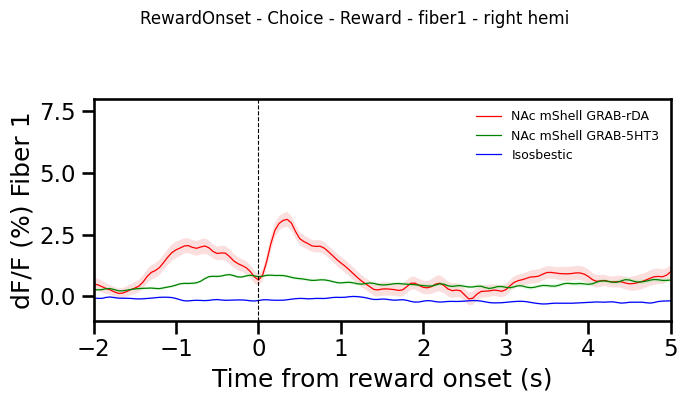

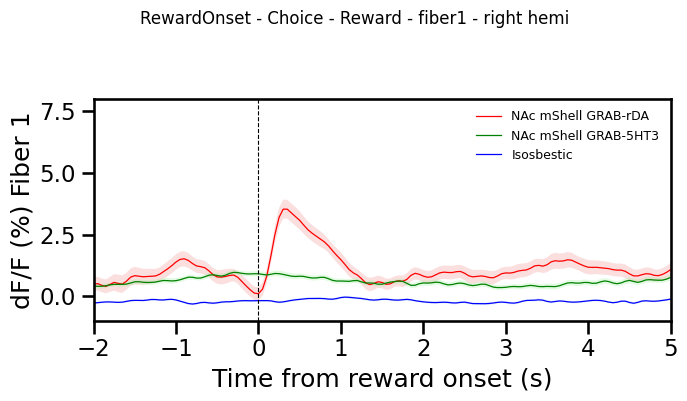

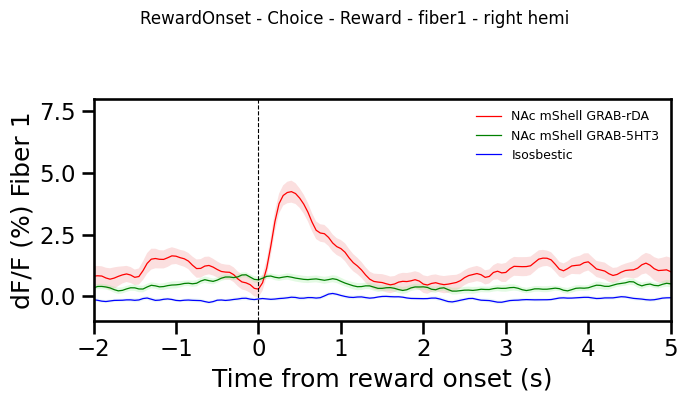

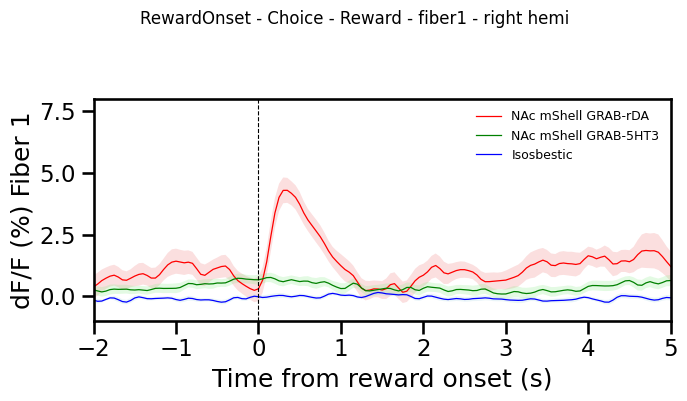

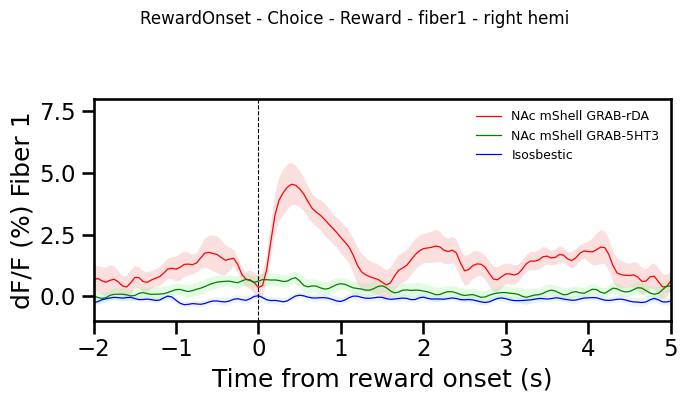

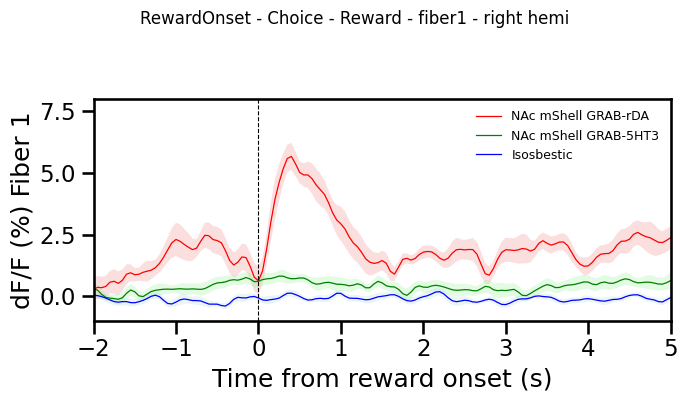

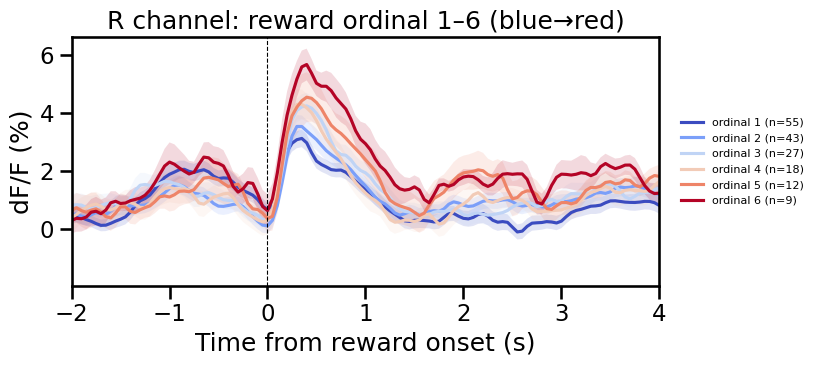

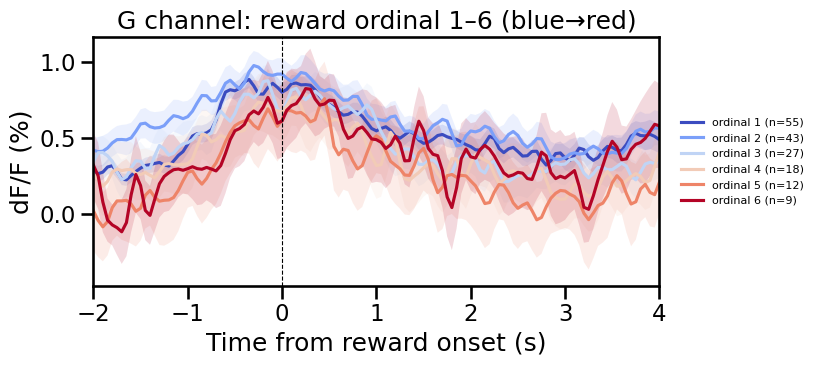

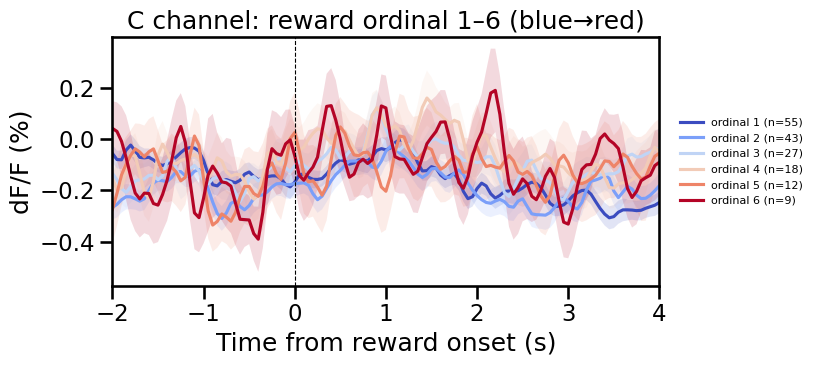

In [17]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Settings
alignment = "RewardOnset"
hemisphere = "Right"
save_ordinal_jpg = True
import os

outdir = os.path.join("ordinal_plots", str(subject_ID))
os.makedirs(outdir, exist_ok=True)


def all_epochs_only_reward_ordinal(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    """
    Return a copy of all_epochs where only reward events with reward-ordinal==ordinal
    remain labeled as is_reward==True (others set False), so get_start_frames selects them.
    Uses patch_number + site_number columns already present.
    """
    ae = all_epochs.copy()

    align_cfg = ALIGNMENT_CFG[alignment]
    epoch_label = align_cfg["epoch_label"]
    

    # all rewarded choice events for this alignment
    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    # compute ordinal among *rewarded* events within each patch_number
    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy()
    ev = ev.sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # For non-selected rewarded events, flip is_reward so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)

    return ae, mask_k

# run ordinal 1-3
ordinal_results = {}

for k in [1, 2, 3, 4, 5, 6]:
    ae_k, mask_k = all_epochs_only_reward_ordinal(all_epochs, alignment="OdorSite", ordinal=k, is_reward=True)
    n_events = int(mask_k.sum())
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue  # nothing to compute/plot for this ordinal

    res = plot_photometry_psth(
        ae_k,
        data1,
        Ctrl_dF_F,
        G_dF_F,
        R_dF_F,
        alignment=alignment,
        is_reward=True,
        subject=subject_ID,        # <-- set yours
        hemisphere=hemisphere,    # <-- set yours
        save_fig=False,
        xlims=(-2, 5),
        ylims=(-1, 8),
    )
    ordinal_results[k] = res


# ---- extract average traces (mean across trials) ----
# psth_* shape: (time, 1, trials)
t_rel = ordinal_results[1]["t_rel"]

avg = {}
sem = {}
for k, res in ordinal_results.items():
    avg[k] = {}
    sem[k] = {}
    for ch_name, psth in [("R", res["psth_R"]), ("G", res["psth_G"]), ("C", res["psth_C"])]:
        P = psth[:, 0, :]  # (time, trials)
        avg[k][ch_name] = np.nanmean(P, axis=1)
        sem[k][ch_name] = np.nanstd(P, axis=1, ddof=1) / np.sqrt(np.sum(~np.isnan(P), axis=1))

# ---- plot overlays: ordinal #1..#6 for each channel ----
import matplotlib as mpl
import matplotlib.pyplot as plt

ordinals_to_plot = [1, 2, 3, 4, 5, 6]

# Blue -> Red gradient (use "coolwarm"; you can also try "bwr")
cmap = mpl.cm.get_cmap("coolwarm")
norm = mpl.colors.Normalize(vmin=min(ordinals_to_plot), vmax=max(ordinals_to_plot))

# --- n trials per ordinal (count non-NaN trials) ---
# Uses the channel you're already plotting; choose one that's always present (R here).
n_trials = {}
for k, res in ordinal_results.items():
    P = res["psth_R"][:, 0, :]                 # (time, trials)
    n_trials[k] = int(np.sum(~np.isnan(P).all(axis=0)))  # trials with any non-NaN


for ch_name in ["R", "G", "C"]:
    fig, ax = plt.subplots(figsize=(11, 4))

    for k in ordinals_to_plot:
        if k not in avg:
            continue

        color = cmap(norm(k))
        label = f"ordinal {k} (n={n_trials.get(k, 0)})"
        ax.plot(t_rel, avg[k][ch_name], color=color, label=label)
        ax.fill_between(
            t_rel,
            avg[k][ch_name] - sem[k][ch_name],
            avg[k][ch_name] + sem[k][ch_name],
            color=color,
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xlim(-2, 4)
    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlabel(ALIGNMENT_CFG.get(alignment, {}).get("xlabel", f"Time from {alignment} (s)"))
    ax.set_ylabel("dF/F (%)")
    ax.set_title(f"{ch_name} channel: reward ordinal 1–6 (blue→red)")

    # legend outside (right)
    ax.legend(
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
    )

    # make room on the right for legend
    fig.tight_layout(rect=[0, 0, 0.78, 1])

    # save (optional)
    if save_ordinal_jpg:
        fname = f"m{subject_ID}_{session_date}_{hemisphere}_{alignment}_{ch_name}_ordinals.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()


ordinal 1: n_events = 55
ordinal 2: n_events = 43
ordinal 3: n_events = 27
ordinal 4: n_events = 18
ordinal 5: n_events = 12
ordinal 6: n_events = 9


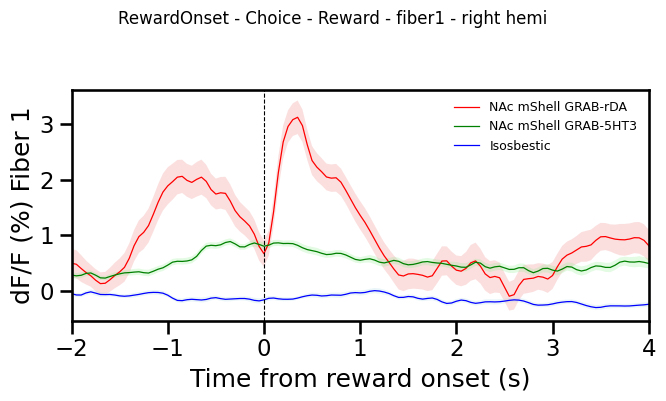

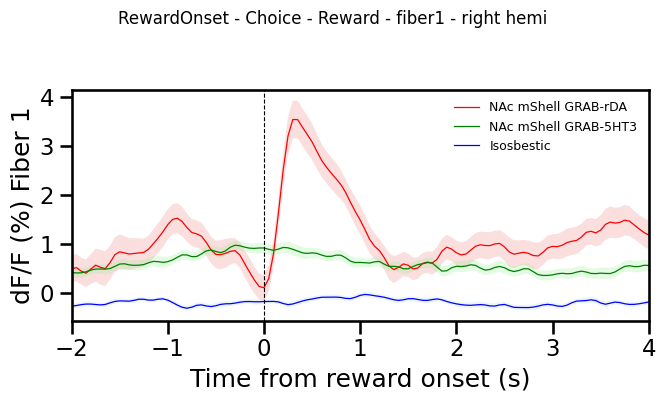

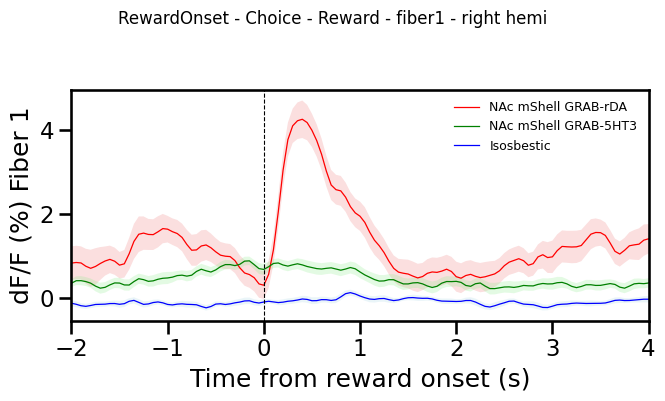

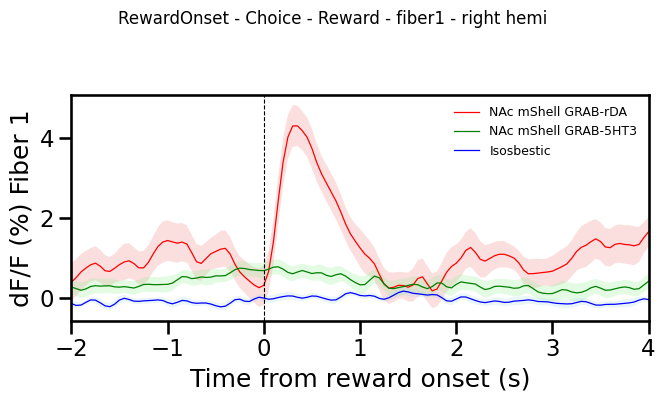

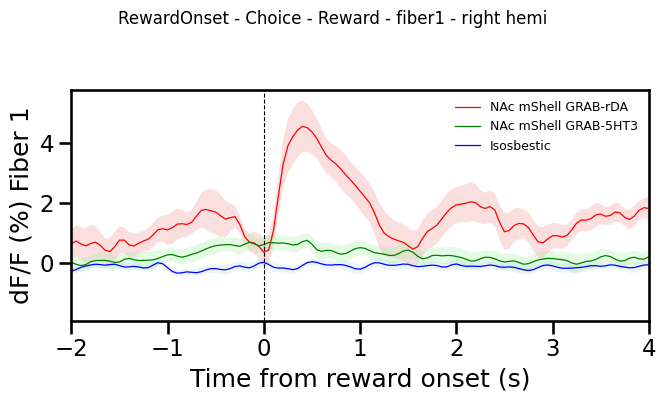

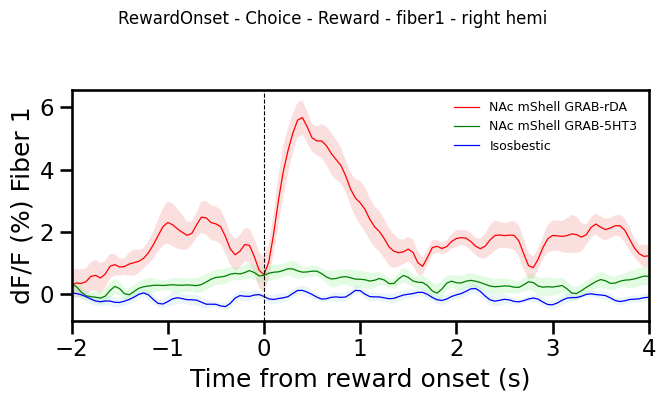

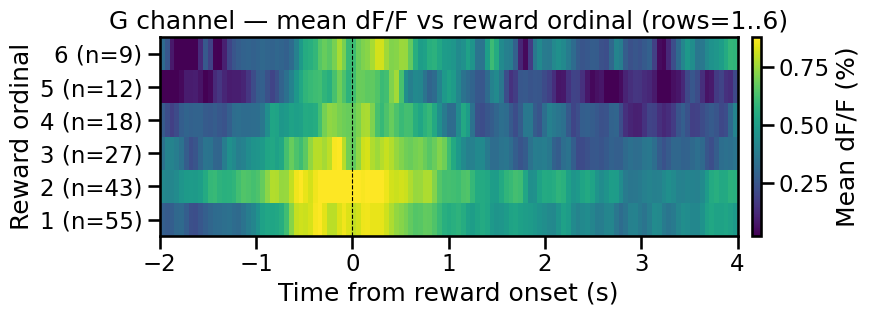

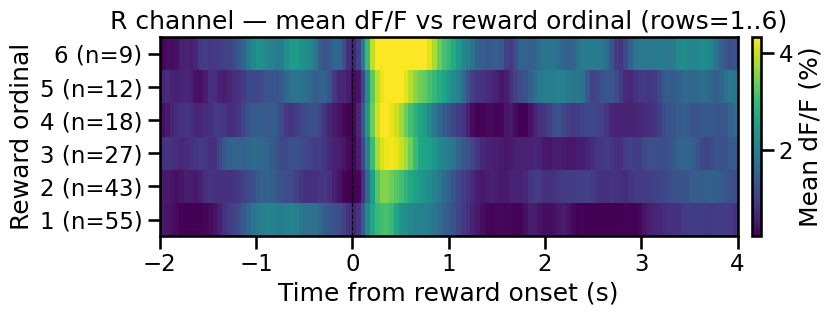

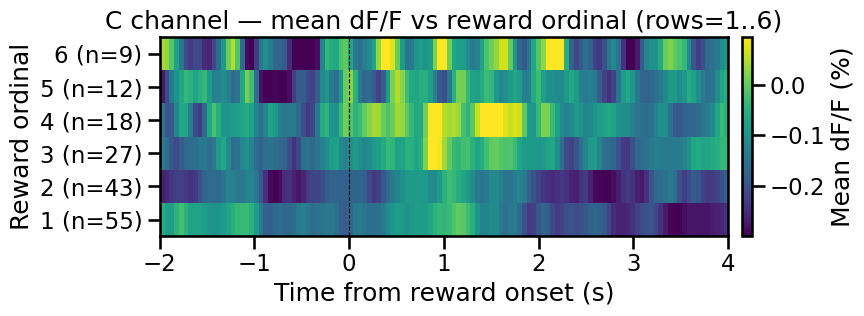

In [18]:
#Heatmap Ordinals
import os
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Settings
# ----------------------------
ordinals_to_plot = [1, 2, 3, 4, 5, 6]
xlims = (-2, 4)
alignment = "RewardOnset"
hemisphere = "Right"
subject = subject_ID
is_reward = True

# saving (match overlay logic)
save_ordinal_jpg = True
outdir = os.path.join("ordinal_plots", str(subject_ID))
os.makedirs(outdir, exist_ok=True)


# ----------------------------
# Helper: select only rewarded events of a given ordinal
# ----------------------------
def all_epochs_only_reward_ordinal(all_epochs, *, alignment="OdorSite", ordinal=1, is_reward=True):
    ae = all_epochs.copy()

    epoch_label = ALIGNMENT_CFG[alignment]["epoch_label"]

    mask_all = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["is_reward"].astype(bool) == bool(is_reward))
    )

    ev = ae.loc[mask_all, ["patch_number", "site_number"]].copy().sort_index()
    ev["reward_ordinal"] = ev.groupby("patch_number").cumcount() + 1

    mask_k = mask_all.copy()
    mask_k.loc[mask_all] = (ev["reward_ordinal"] == ordinal).values

    # flip is_reward for non-selected events so get_start_frames ignores them
    ae.loc[mask_all & (~mask_k), "is_reward"] = (not is_reward)
    return ae, mask_k


# ----------------------------
# Pass 1: run PSTHs per ordinal, cache means
# ----------------------------
ordinal_results = {}
n_events_by_k = {}

for k in ordinals_to_plot:
    ae_k, mask_k = all_epochs_only_reward_ordinal(all_epochs, alignment=alignment, ordinal=k, is_reward=is_reward)
    n_events = int(mask_k.sum())
    n_events_by_k[k] = n_events
    print(f"ordinal {k}: n_events = {n_events}")

    if n_events == 0:
        continue

    res = plot_photometry_psth(
        ae_k, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment=alignment,
        is_reward=is_reward,
        subject=subject,
        hemisphere=hemisphere,
        save_fig=False,
        xlims=xlims,
        ylims=None,   # heatmap will set its own scaling
    )
    ordinal_results[k] = res

# Require at least one ordinal to exist
if len(ordinal_results) == 0:
    raise ValueError("No ordinals had events; nothing to plot.")

# Timebase (assume consistent across ordinals)
t_rel = next(iter(ordinal_results.values()))["t_rel"]
t_rel = np.asarray(t_rel)

# columns within the requested xlims
tm = (t_rel >= xlims[0]) & (t_rel <= xlims[1])
t_plot = t_rel[tm]

# ----------------------------
# Build heatmap matrices: (6 rows, T cols) for each channel
# Each row is mean across trials at ROI-axis=0
# ----------------------------
def psth_to_mean_row(psth):
    """psth: (time, 1, trials) -> (time,) mean across trials"""
    P = np.asarray(psth)[:, 0, :]  # (time, trials)
    return np.nanmean(P, axis=1)

# allocate with NaNs for missing ordinals
heat = {ch: np.full((len(ordinals_to_plot), tm.sum()), np.nan, float) for ch in ["G", "R", "C"]}

for row_i, k in enumerate(ordinals_to_plot):
    if k not in ordinal_results:
        continue
    res = ordinal_results[k]
    heat["G"][row_i, :] = psth_to_mean_row(res["psth_G"])[tm]
    heat["R"][row_i, :] = psth_to_mean_row(res["psth_R"])[tm]
    heat["C"][row_i, :] = psth_to_mean_row(res["psth_C"])[tm]

# ----------------------------
# Plot: one heatmap per channel
# ----------------------------
xlabel = ALIGNMENT_CFG.get(alignment, {}).get("xlabel", f"Time from {alignment} (s)")

for ch in ["G", "R", "C"]:
    M = heat[ch]

    finite = M[np.isfinite(M)]
    if finite.size == 0:
        print(f"{ch}: no finite values; skipping")
        continue
    vmin, vmax = np.percentile(finite, [2, 98])

    fig, ax = plt.subplots(figsize=(9, 3.5))

    im = ax.imshow(
        M,
        aspect="auto",
        origin="lower",
        extent=[t_plot[0], t_plot[-1], 0.5, len(ordinals_to_plot) + 0.5],
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.axvline(0, color="k", ls="--", lw=0.8)

    # alignment-aware xlabel
    ax.set_xlabel(xlabel)

    ax.set_ylabel("Reward ordinal")
    ax.set_yticks(ordinals_to_plot)

    # show event counts per ordinal on the y tick labels
    yticklabels = [f"{k} (n={n_events_by_k.get(k,0)})" for k in ordinals_to_plot]
    ax.set_yticklabels(yticklabels)

    ax.set_title(f"{ch} channel — mean dF/F vs reward ordinal (rows=1..6)")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Mean dF/F (%)")

    # make sure everything fits, especially colorbar, when saving
    fig.tight_layout()

    # save (optional) — Subject ID, date, hemisphere, alignment, color channel
    if save_ordinal_jpg:
        fname = f"m{subject}_{session_date}_{hemisphere}_{alignment}_{ch}_ordinals_heatmap.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()



CUE  (0.5, 1.0)s: rewarded n=183 mean=1.971 sem=1.248 | unrewarded n=211 mean=0.1111 sem=0.7821
REW  (1.5, 2.5)s: rewarded n=183 mean=15.59 sem=1.145 | unrewarded n=211 mean=-2.234 sem=0.8655
Cue window (0.5, 1.0): Welch t=1.26, p=0.208 (nR=183, nU=211)
Rew window (1.5, 2.5): Welch t=12.4, p=1.33e-29 (nR=183, nU=211)


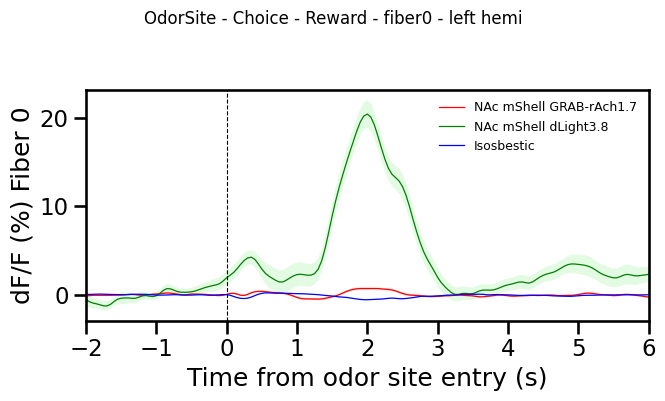

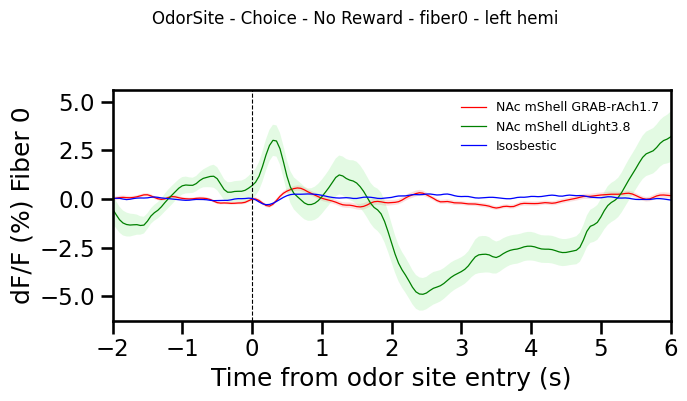

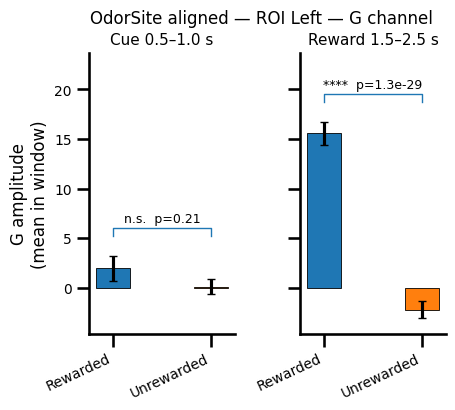

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# SETTINGS
# =========================
ALIGNMENT = "OdorSite"      # whatever you used for PSTH alignment
CUE_WIN = (0.5, 1.0)
REW_WIN = (1.5, 2.5)

SUBJECT = 788731
HEMISPHERE = "Left"
XLIMS = (-2, 6)
YLIMS = None

CHANNEL = "G"               # "G" or "R" or "C"

# =========================
# Helpers
# =========================

def window_mean_per_trial(t_rel, X_time_by_trials, win):
    """Return per-trial mean in time window win=(t0,t1)."""
    t_rel = np.asarray(t_rel, float).squeeze()
    X = np.asarray(X_time_by_trials, float)
    mask = (t_rel >= win[0]) & (t_rel <= win[1])
    if mask.sum() < 2:
        raise ValueError(f"Window {win} has too few samples. Check t_rel range: {t_rel.min()}..{t_rel.max()}")
    return np.nanmean(X[mask, :], axis=0)  # (trials,)

def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, 0
    m = np.mean(x)
    se = np.std(x, ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0
    return m, se, len(x)

# =========================
# 1) Run PSTH for rewarded vs unrewarded
# =========================
res_rew = plot_photometry_psth(
    all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
    alignment=ALIGNMENT, is_reward=True,
    subject=SUBJECT, hemisphere=HEMISPHERE,
    save_fig=False, xlims=XLIMS, ylims=YLIMS
)

res_unr = plot_photometry_psth(
    all_epochs, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
    alignment=ALIGNMENT, is_reward=False,
    subject=SUBJECT, hemisphere=HEMISPHERE,
    save_fig=False, xlims=XLIMS, ylims=YLIMS
)

t_rel = res_rew["t_rel"]

# pick channel
key = {"G": "psth_G", "R": "psth_R", "C": "psth_C"}[CHANNEL]
X_rew = (res_rew[key])[:,0,:]
X_unr = (res_unr[key])[:,0,:]

# =========================
# 2) Compute per-trial window amplitudes
# =========================
cue_rew = window_mean_per_trial(t_rel, X_rew, CUE_WIN)
cue_unr = window_mean_per_trial(t_rel, X_unr, CUE_WIN)

rew_rew = window_mean_per_trial(t_rel, X_rew, REW_WIN)
rew_unr = window_mean_per_trial(t_rel, X_unr, REW_WIN)

# summary stats
cue_rew_m, cue_rew_se, n1 = mean_sem(cue_rew)
cue_unr_m, cue_unr_se, n2 = mean_sem(cue_unr)
rew_rew_m, rew_rew_se, n3 = mean_sem(rew_rew)
rew_unr_m, rew_unr_se, n4 = mean_sem(rew_unr)

print(f"CUE  {CUE_WIN}s: rewarded n={n1} mean={cue_rew_m:.4g} sem={cue_rew_se:.4g} | unrewarded n={n2} mean={cue_unr_m:.4g} sem={cue_unr_se:.4g}")
print(f"REW  {REW_WIN}s: rewarded n={n3} mean={rew_rew_m:.4g} sem={rew_rew_se:.4g} | unrewarded n={n4} mean={rew_unr_m:.4g} sem={rew_unr_se:.4g}")

from scipy import stats
import numpy as np

def welch_ttest(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    t, p = stats.ttest_ind(a, b, equal_var=False)
    return t, p, len(a), len(b)

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

# Cue window stats
t_cue, p_cue, ncue_r, ncue_u = welch_ttest(cue_rew, cue_unr)
# Reward window stats
t_rew, p_rew, nrew_r, nrew_u = welch_ttest(rew_rew, rew_unr)

print(f"Cue window {CUE_WIN}: Welch t={t_cue:.3g}, p={p_cue:.3g} (nR={ncue_r}, nU={ncue_u})")
print(f"Rew window {REW_WIN}: Welch t={t_rew:.3g}, p={p_rew:.3g} (nR={nrew_r}, nU={nrew_u})")

# =========================
# 3) Bar plots (mean ± SEM) — skinnier + different colors
# =========================
labels = ["Rewarded", "Unrewarded"]

# skinny look
BAR_W = 0.28
CAP = 3
ROT = 25

# choose two distinct colors (edit if you want)
COL_REW = "tab:blue"
COL_UNR = "tab:orange"

fig, axes = plt.subplots(
    1, 2,
    figsize=(4.6, 3.8),   # <-- much skinnier overall
    sharey=True
)

# positions (keep some gap)
x = np.array([0.0, 0.8])

# Cue window
axes[0].bar(
    x,
    [cue_rew_m, cue_unr_m],
    yerr=[cue_rew_se, cue_unr_se],
    width=BAR_W,
    capsize=CAP,
    color=[COL_REW, COL_UNR],
    edgecolor="k",
    linewidth=0.6
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=ROT, ha="right")
axes[0].set_title(f"Cue {CUE_WIN[0]}–{CUE_WIN[1]} s", fontsize=11)
axes[0].set_ylabel(f"{CHANNEL} amplitude\n(mean in window)", fontsize=12)

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

def add_sig(ax, x1, x2, y_top_of_bars, yr, p, lift_frac=0.10, h_frac=0.04, text_frac=0.015):
    """
    Draw bracket + single-line annotation above bars without clipping.

    y_top_of_bars: max(mean+SEM) for the bars in THIS subplot
    yr: y-range (shared for both axes)
    lift_frac: how far above bars to place bracket bottom (fraction of yr)
    h_frac: bracket height (fraction of yr)
    text_frac: text gap above bracket (fraction of yr)
    """
    y_base = y_top_of_bars + lift_frac * yr
    h = h_frac * yr

    ax.plot([x1, x1, x2, x2], [y_base, y_base+h, y_base+h, y_base], lw=1)

    ax.text((x1+x2)/2, y_base+h + text_frac*yr,
            f"{p_to_stars(p)}  p={p:.2g}",
            ha="center", va="bottom", fontsize=9)

# ---- set y-lims once so nothing clips (works well with sharey=True) ----
ymax_data = np.nanmax([
    cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se,
    rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se
])
ymin_data = np.nanmin([
    cue_rew_m - cue_rew_se, cue_unr_m - cue_unr_se,
    rew_rew_m - rew_rew_se, rew_unr_m - rew_unr_se
])
yr = (ymax_data - ymin_data) if (np.isfinite(ymax_data - ymin_data) and ymax_data > ymin_data) else 1.0

TOP_PAD = 0.35 * yr   # enough for bracket+text
BOT_PAD = 0.08 * yr
for ax in axes:
    ax.set_ylim(ymin_data - BOT_PAD, ymax_data + TOP_PAD)

# ---- add sig to each subplot using its own tallest bar height ----
cue_top = np.nanmax([cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se])
rew_top = np.nanmax([rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se])

add_sig(axes[0], x[0], x[1], cue_top, yr, p_cue)
add_sig(axes[1], x[0], x[1], rew_top, yr, p_rew)


# After you draw the cue bars:
ymax0 = np.nanmax([cue_rew_m + cue_rew_se, cue_unr_m + cue_unr_se])
ymin0 = np.nanmin([cue_rew_m - cue_rew_se, cue_unr_m - cue_unr_se])
rng0 = (ymax0 - ymin0) if ymax0 > ymin0 else 1.0

# Reward window
axes[1].bar(
    x,
    [rew_rew_m, rew_unr_m],
    yerr=[rew_rew_se, rew_unr_se],
    width=BAR_W,
    capsize=CAP,
    color=[COL_REW, COL_UNR],
    edgecolor="k",
    linewidth=0.6
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=ROT, ha="right")
axes[1].set_title(f"Reward {REW_WIN[0]}–{REW_WIN[1]} s", fontsize=11)

# After you draw the reward bars:
ymax1 = np.nanmax([rew_rew_m + rew_rew_se, rew_unr_m + rew_unr_se])
ymin1 = np.nanmin([rew_rew_m - rew_rew_se, rew_unr_m - rew_unr_se])
rng1 = (ymax1 - ymin1) if ymax1 > ymin1 else 1.0

# aesthetics
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=10)

# --- titles ---
fig.suptitle(f"{ALIGNMENT} aligned — ROI {HEMISPHERE} — {CHANNEL} channel", y=0.965, fontsize=12)

# --- tighten the vertical spacing between suptitle and subplot titles ---
fig.subplots_adjust(top=0.85, wspace=0.45)  # top controls the gap; increase top -> less gap

# If you also use tight_layout, use it FIRST with a rect, then subplots_adjust LAST:
# plt.tight_layout(rect=[0, 0, 1, 0.92])
# fig.subplots_adjust(top=0.86, wspace=0.45)




Shared y-lims: (-30, 50)


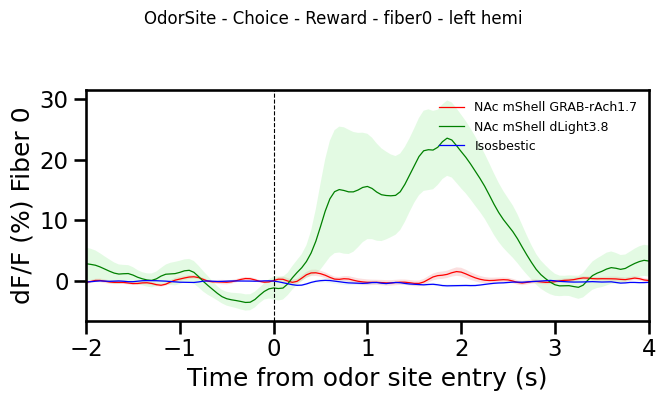

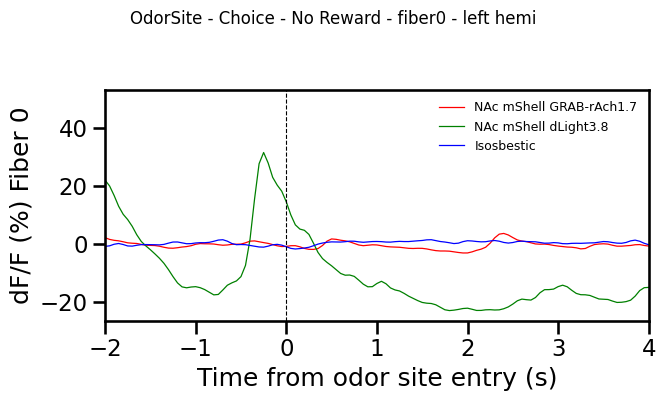

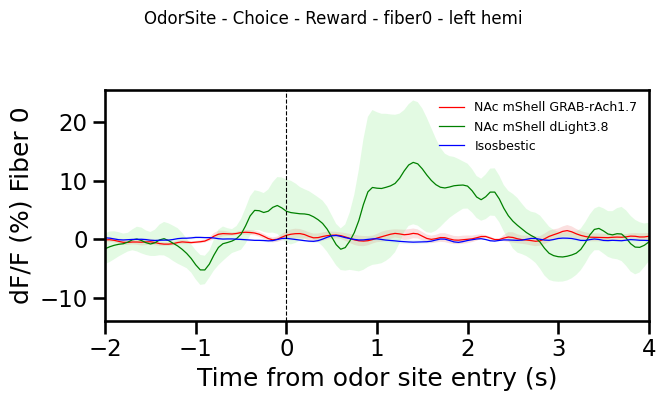

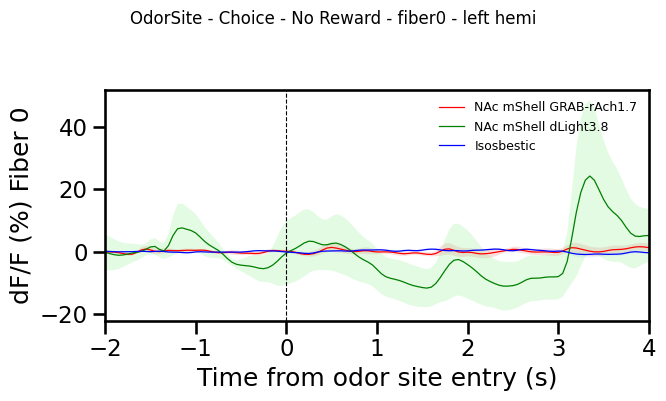

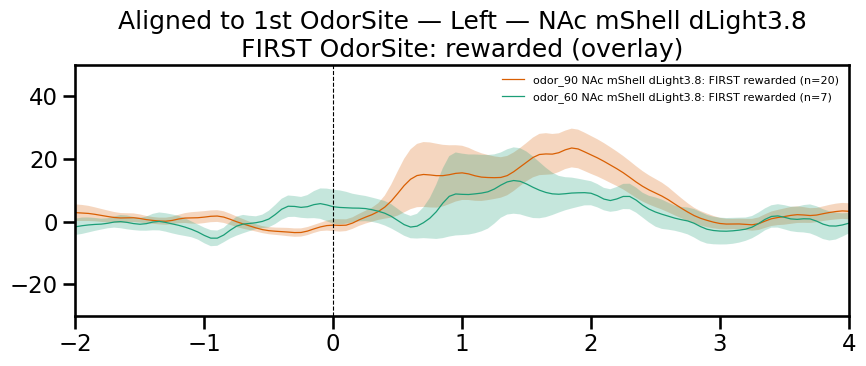

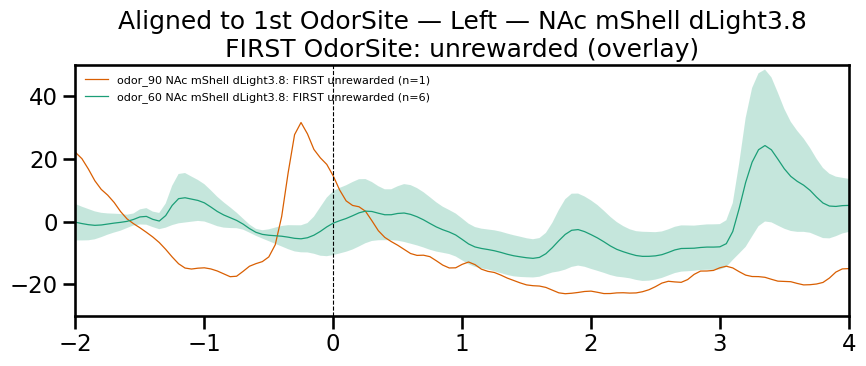

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# USER SETTINGS
# ============================
ODORS = ["odor_90", "odor_60"]
XLIMS = (-2, 4)

# Pick which hemisphere + which photometry channel to plot
HEMISPHERE = "Left"          # "Left" or "Right"
CHANNEL = "G"                 # "G", "R", or "C" (if your plotter returns Ctrl)

SUBJECT = subject_ID

# Padding fraction for shared y-lims
YLIM_PAD_FRAC = 0.05

# OPTIONAL: if you want to hard-set ylims, set to tuple like (-3, 4), else None
FORCE_YLIMS = (-30,50)  # e.g. (-3, 4)

# ============================
# Color key (odor_60 vs odor_90)
# ============================
color1 = "#d95f02"
color2 = "#1b9e77"
color3 = "#7570b3"
color4 = "#e7298a"

color_dict_label = {
    "InterSite": "#808080",
    "InterPatch": "#b3b3b3",
    "PatchZ": "#d95f02",
    "PatchZA": "#d95f02",
    "PatchZB": "#d95f02",
    "PatchB": "#d95f02",
    "PatchA": "#7570b3",
    "PatchC": "#1b9e77",
    "Alpha-pinene": "#1b9e77",
    "Methyl Butyrate": "#7570b3",
    "Amyl Acetate": "#d95f02",
    "Fenchone": "#7570b3",
    "Dipropyl sulfide": "#7570b3",
    "Dypropil sulfide": "#7570b3",
    "Hexanal": "#1b9e77",
    "Pentyl acetate": "#d95f02",
    "S": color1,
    "D": color2,
    "N": color3,
    "Do": color1,
    "None": color4,
    "odor_0": color3,
    "odor_60": color2,
    "odor_90": color1,
    "odor_fast": "#d95f02",
    "odor_slow": "#1b9e77",
    "A": color1,
    "B": color2,
    "C": color3,
    "OdorA": color1,
    "OdorB": color2,
    "OdorC": color3,
}

# ============================
# Helpers
# ============================
def odor_mask_from_patch_label(ae: pd.DataFrame, odor_name: str) -> pd.Series:
    if "patch_label" not in ae.columns:
        raise KeyError("Expected odor identity in all_epochs['patch_label'], but that column is missing.")
    return ae["patch_label"].astype(str) == odor_name

def first_odorsite_mask(ae: pd.DataFrame) -> pd.Series:
    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain 'patch_number'.")

    odor_rows = (ae["label"] == "OdorSite") & ae["patch_number"].notna()
    out = pd.Series(False, index=ae.index)

    if "site_number" in ae.columns:
        mins = ae.loc[odor_rows].groupby("patch_number")["site_number"].transform("min")
        out.loc[odor_rows] = (ae.loc[odor_rows, "site_number"] == mins).values
        return out

    tmp = ae.loc[odor_rows, ["patch_number"]].copy()
    tmp["t"] = ae.loc[odor_rows].index.values.astype(float)
    tmin = tmp.groupby("patch_number")["t"].transform("min")
    out.loc[odor_rows] = (tmp["t"] == tmin).values
    return out

def robust_min_max(x):
    x = np.asarray(x, float)
    if x.size == 0 or np.all(np.isnan(x)):
        return None, None
    return float(np.nanmin(x)), float(np.nanmax(x))

def get_channel_trials(res: dict, channel: str) -> np.ndarray:
    """
    Returns array shaped (T, Ntrials) for selected channel from plot_photometry_psth result dict.
    Expects res keys like 'psth_G', 'psth_R', 'psth_Ctrl' or 'psth_C' depending on your function.
    """
    ch = channel.upper()
    key_map = {
        "G": ["psth_G"],
        "R": ["psth_R"],
        "C": ["psth_C", "psth_Ctrl", "psth_Ctrl_dF_F", "psth_CtrlDF_F"],
    }
    if ch not in key_map:
        raise ValueError(f"CHANNEL must be one of {list(key_map.keys())}, got {channel!r}")

    for k in key_map[ch]:
        if k in res:
            arr = np.asarray(res[k])
            # expected shape (T, n_roi, n_trials) -> take ROI 0
            return arr[:, 0, :]

    raise KeyError(f"Could not find a PSTH key for CHANNEL={channel!r}. Tried: {key_map[ch]}")

# ============================
# Build cache per odor (rewarded + unrewarded)
# ============================
cache = {}  # odor_name -> dict(t_rel, rew(T,N), unr(T,N))
global_min = np.inf
global_max = -np.inf

ae0 = all_epochs.sort_index().copy()

for odor_name in ODORS:
    ae = ae0.copy()

    m_odor = odor_mask_from_patch_label(ae, odor_name)
    m_first_all = first_odorsite_mask(ae)
    m_first = m_first_all & m_odor

    # Keep only FIRST odorsite for this odor as "OdorSite"; relabel other OdorSite rows so they won't align
    ae.loc[(ae["label"] == "OdorSite") & (~m_first), "label"] = "OdorSite_other"

    res_rew = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=True,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,
    )
    res_unr = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=False,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,
    )

    t_rel = res_rew["t_rel"]
    ch_rew = get_channel_trials(res_rew, CHANNEL)  # (T, N)
    ch_unr = get_channel_trials(res_unr, CHANNEL)  # (T, N)

    cache[odor_name] = dict(t_rel=t_rel, rew=ch_rew, unr=ch_unr)

    for arr in (ch_rew, ch_unr):
        mn, mx = robust_min_max(arr)
        if mn is None:
            continue
        global_min = min(global_min, mn)
        global_max = max(global_max, mx)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise ValueError("Could not compute shared y-lims (all traces empty/NaN).")

pad = YLIM_PAD_FRAC * (global_max - global_min + 1e-9)
SHARED_YLIMS = (global_min - pad, global_max + pad)
if FORCE_YLIMS is not None:
    SHARED_YLIMS = FORCE_YLIMS

print("Shared y-lims:", SHARED_YLIMS)

# ============================
# Labels for chosen hemisphere/channel
# ============================
try:
    cfg = SUBJECT_CFG[SUBJECT][HEMISPHERE]
    g_label = cfg.get("G_label", "Green")
    r_label = cfg.get("R_label", "Red")
    c_label = cfg.get("C_label", cfg.get("Ctrl_label", "Isosbestic"))
except Exception:
    g_label, r_label, c_label = "Green", "Red", "Isosbestic"

channel_label_map = {"G": g_label, "R": r_label, "C": c_label}
CH_LABEL = channel_label_map.get(CHANNEL.upper(), CHANNEL.upper())

# ============================
# Overlay plots:
#   1) Rewarded: odor_90 vs odor_60 overlaid
#   2) Unrewarded: odor_90 vs odor_60 overlaid
# ============================
odor_a, odor_b = ODORS[0], ODORS[1]
t_rel_a = cache[odor_a]["t_rel"]
t_rel_b = cache[odor_b]["t_rel"]

# If t_rel differs slightly between odors, we still plot each with its own x; usually they match.
# (If you want to enforce identical t_rel, assert np.allclose(t_rel_a, t_rel_b).)

col_a = color_dict_label.get(odor_a, "k")
col_b = color_dict_label.get(odor_b, "0.5")

plt.figure(figsize=(9, 4))
plot_mean_sem(t_rel_a, cache[odor_a]["rew"], col_a, col_a, f"{odor_a} {CH_LABEL}: FIRST rewarded (n={cache[odor_a]['rew'].shape[1]})")
plot_mean_sem(t_rel_b, cache[odor_b]["rew"], col_b, col_b, f"{odor_b} {CH_LABEL}: FIRST rewarded (n={cache[odor_b]['rew'].shape[1]})")
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlim(*XLIMS)
plt.ylim(*SHARED_YLIMS)
plt.title(f"Aligned to 1st OdorSite — {HEMISPHERE} — {CH_LABEL}\nFIRST OdorSite: rewarded (overlay)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plot_mean_sem(t_rel_a, cache[odor_a]["unr"], col_a, col_a, f"{odor_a} {CH_LABEL}: FIRST unrewarded (n={cache[odor_a]['unr'].shape[1]})")
plot_mean_sem(t_rel_b, cache[odor_b]["unr"], col_b, col_b, f"{odor_b} {CH_LABEL}: FIRST unrewarded (n={cache[odor_b]['unr'].shape[1]})")
plt.axvline(0, color="k", ls="--", lw=0.8)
plt.xlim(*XLIMS)
plt.ylim(*SHARED_YLIMS)
plt.title(f"Aligned to 1st OdorSite — {HEMISPHERE} — {CH_LABEL}\nFIRST OdorSite: unrewarded (overlay)")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


Shared y-lims: (-11.466793738788146, 24.192024333541422)


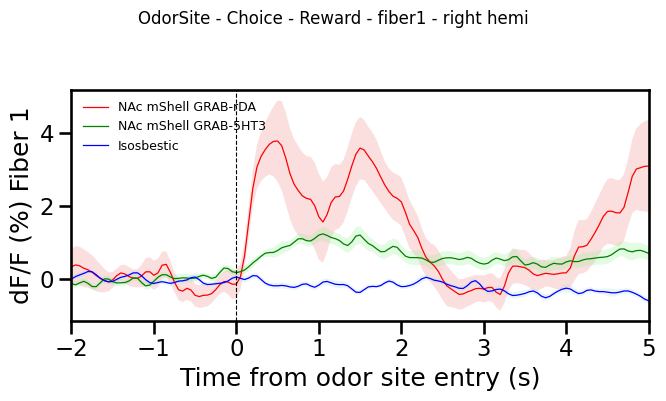

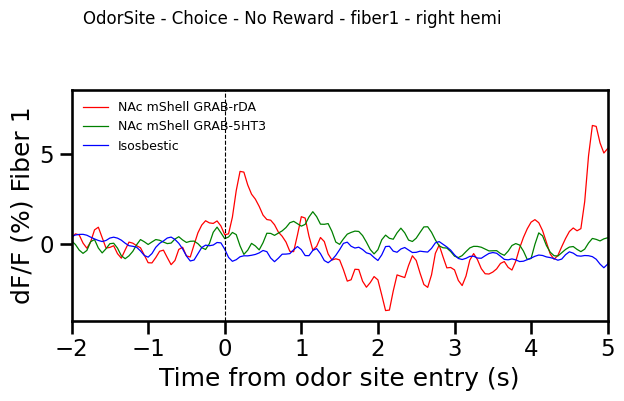

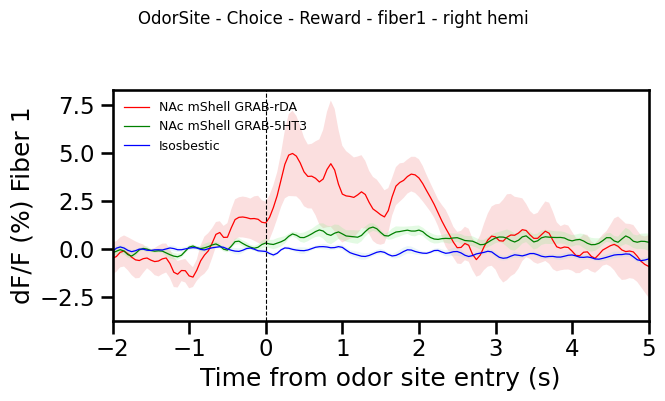

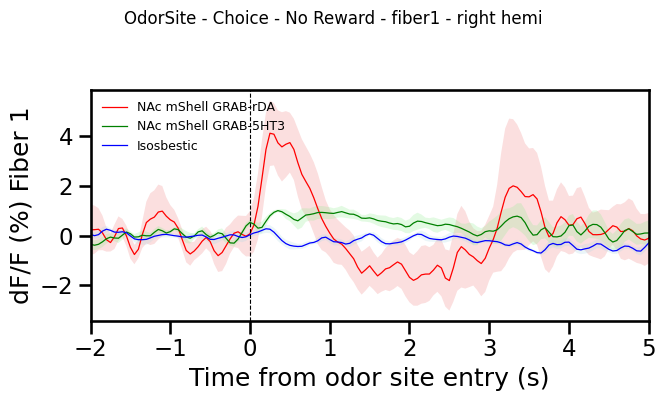

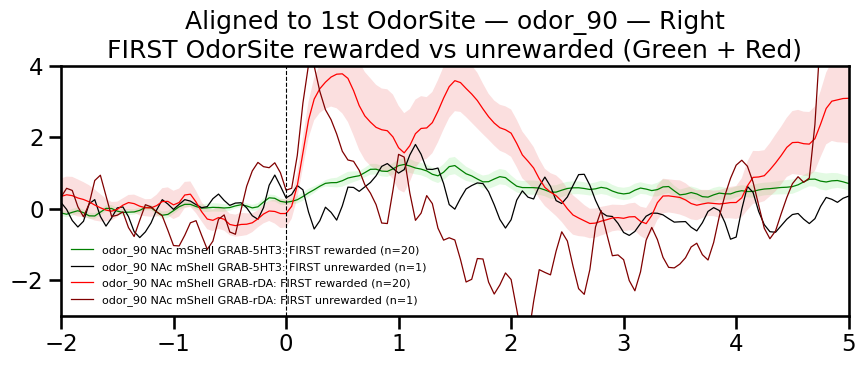

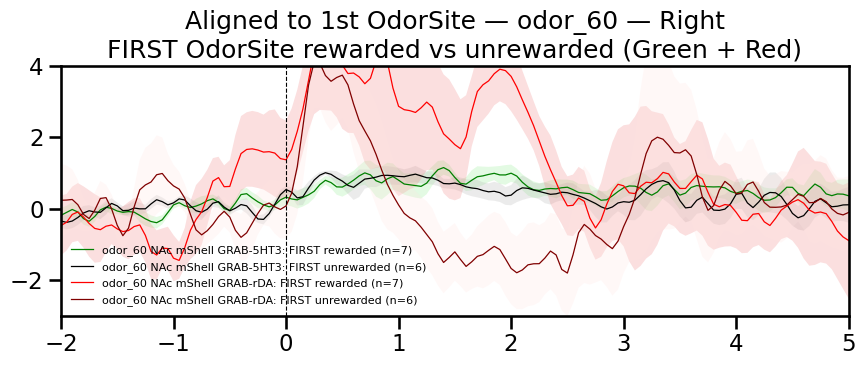

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# USER SETTINGS
# ============================
ODORS = ["odor_90", "odor_60"]
XLIMS = (-2, 5)
HEMISPHERE = "Right"
SUBJECT = subject_ID

# Padding fraction for shared y-lims
YLIM_PAD_FRAC = 0.05

# ============================
# Helpers
# ============================
def odor_mask_from_patch_label(ae: pd.DataFrame, odor_name: str) -> pd.Series:
    if "patch_label" not in ae.columns:
        raise KeyError("Expected odor identity in all_epochs['patch_label'], but that column is missing.")
    return ae["patch_label"].astype(str) == odor_name

def first_odorsite_mask(ae: pd.DataFrame) -> pd.Series:
    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain 'patch_number'.")

    odor_rows = (ae["label"] == "OdorSite") & ae["patch_number"].notna()
    out = pd.Series(False, index=ae.index)

    if "site_number" in ae.columns:
        mins = ae.loc[odor_rows].groupby("patch_number")["site_number"].transform("min")
        out.loc[odor_rows] = (ae.loc[odor_rows, "site_number"] == mins).values
        return out

    tmp = ae.loc[odor_rows, ["patch_number"]].copy()
    tmp["t"] = ae.loc[odor_rows].index.values.astype(float)
    tmin = tmp.groupby("patch_number")["t"].transform("min")
    out.loc[odor_rows] = (tmp["t"] == tmin).values
    return out

def robust_min_max(x):
    """Min/max ignoring NaNs; returns (None,None) if all-NaN or empty."""
    x = np.asarray(x, float)
    if x.size == 0 or np.all(np.isnan(x)):
        return None, None
    return float(np.nanmin(x)), float(np.nanmax(x))


# ============================
# Pass 1: compute shared y-lims across odors
# ============================
cache = {}  # odor_name -> dict(res_rew,res_unr,t_rel,g_rew,g_unr,r_rew,r_unr)
global_min = np.inf
global_max = -np.inf

for odor_name in ODORS:
    ae = all_epochs.sort_index().copy()

    m_odor = odor_mask_from_patch_label(ae, odor_name)
    m_first_all = first_odorsite_mask(ae)
    m_first = m_first_all & m_odor
    ae.loc[(ae["label"] == "OdorSite") & (~m_first), "label"] = "OdorSite_other"

    res_rew = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=True,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,   # let us set shared y later
    )
    res_unr = plot_photometry_psth(
        ae, data1, Ctrl_dF_F, G_dF_F, R_dF_F,
        alignment="OdorSite", is_reward=False,
        subject=SUBJECT, hemisphere=HEMISPHERE,
        save_fig=False, xlims=XLIMS, ylims=None,
    )

    t_rel = res_rew["t_rel"]
    g_rew = np.asarray(res_rew["psth_G"])[:, 0, :]
    g_unr = np.asarray(res_unr["psth_G"])[:, 0, :]
    r_rew = np.asarray(res_rew["psth_R"])[:, 0, :]
    r_unr = np.asarray(res_unr["psth_R"])[:, 0, :]

    cache[odor_name] = dict(
        t_rel=t_rel, g_rew=g_rew, g_unr=g_unr, r_rew=r_rew, r_unr=r_unr
    )

    # update global min/max across all four traces
    for arr in (g_rew, g_unr, r_rew, r_unr):
        mn, mx = robust_min_max(arr)
        if mn is None:
            continue
        global_min = min(global_min, mn)
        global_max = max(global_max, mx)

if not np.isfinite(global_min) or not np.isfinite(global_max):
    raise ValueError("Could not compute shared y-lims (all traces empty/NaN).")

pad = YLIM_PAD_FRAC * (global_max - global_min + 1e-9)
SHARED_YLIMS = (global_min - pad, global_max + pad)
print("Shared y-lims:", SHARED_YLIMS)


# ============================
# Pass 2: plot each odor using shared y-lims
# ============================
try:
    cfg = SUBJECT_CFG[SUBJECT][HEMISPHERE]
    g_label = cfg.get("G_label", "Green")
    r_label = cfg.get("R_label", "Red")
except Exception:
    g_label, r_label = "Green", "Red"

for odor_name in ODORS:
    t_rel = cache[odor_name]["t_rel"]
    g_rew = cache[odor_name]["g_rew"]
    g_unr = cache[odor_name]["g_unr"]
    r_rew = cache[odor_name]["r_rew"]
    r_unr = cache[odor_name]["r_unr"]

    plt.figure(figsize=(9, 4))

    plot_mean_sem(t_rel, g_rew, "g", "lightgreen",
                  f"{odor_name} {g_label}: FIRST rewarded (n={g_rew.shape[1]})")
    plot_mean_sem(t_rel, g_unr, "k", "0.7",
                  f"{odor_name} {g_label}: FIRST unrewarded (n={g_unr.shape[1]})")

    plot_mean_sem(t_rel, r_rew, "r", "lightcoral",
                  f"{odor_name} {r_label}: FIRST rewarded (n={r_rew.shape[1]})")
    plot_mean_sem(t_rel, r_unr, "maroon", "mistyrose",
                  f"{odor_name} {r_label}: FIRST unrewarded (n={r_unr.shape[1]})")

    plt.axvline(0, color="k", ls="--", lw=0.8)
    plt.xlim(*XLIMS)
    plt.ylim(*SHARED_YLIMS)
    plt.ylim(-3,4)
    plt.title(f"Aligned to 1st OdorSite — {odor_name} — {HEMISPHERE}\nFIRST OdorSite rewarded vs unrewarded (Green + Red)")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


odor_90: found 10 OdorSite events


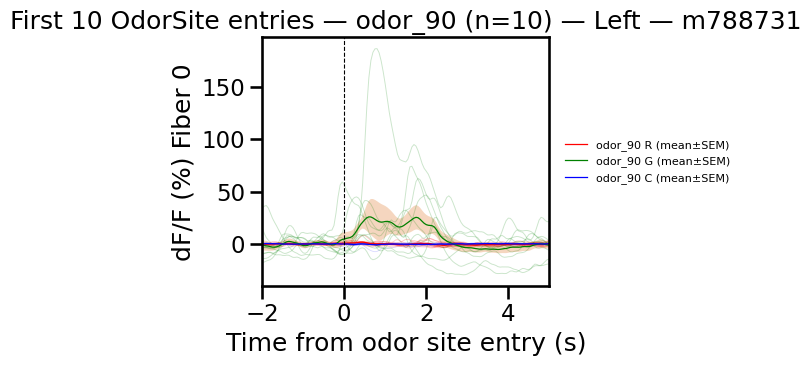

odor_60: found 10 OdorSite events


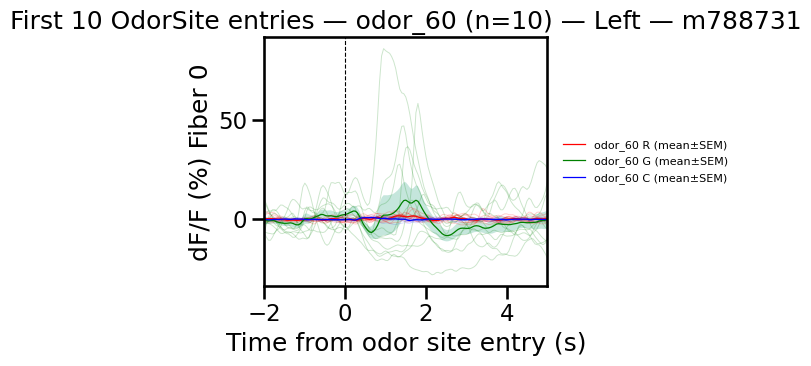

In [46]:
# --- New cell: overlay first 10 OdorSite entries for odor_90 and odor_60 (using all_epochs["patch_label"]) ---

import numpy as np
import matplotlib.pyplot as plt

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='#e7298a'

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 'PatchZ': '#d95f02',
    'PatchZA': '#d95f02', 'PatchZB': '#d95f02', 
    'PatchB': '#d95f02','PatchA': '#7570b3', 
    'PatchC': '#1b9e77',
    'Alpha-pinene': '#1b9e77', 
    'Methyl Butyrate': '#7570b3', 
    'Amyl Acetate': '#d95f02', 
    'Fenchone': '#7570b3', 
    'Dipropyl sulfide': '#7570b3',
    'Dypropil sulfide': '#7570b3',
    'Hexanal': '#1b9e77',
    'Pentyl acetate': '#d95f02',
    'S': color1,
    'D': color2,
    'N': color3,   
    'Do': color1,
    'None': color4, 
    'odor_0': color3,
    'odor_60': color2,
    'odor_90': color1,
    'odor_fast': '#d95f02',
    'odor_slow': '#1b9e77',
    'A': color1,
    'B': color2,
    'C': color3,
    'OdorA': color1,
    'OdorB': color2,
    'OdorC': color3,
}

def first_n_odorsite_startframes_for_patch_label(all_epochs, t, patch_label, n=10):
    """Return startFrames for the first n OdorSite choice events where patch_label matches."""
    epoch_label = ALIGNMENT_CFG["OdorSite"]["epoch_label"]

    ae = all_epochs.sort_index()
    mask = (
        (ae["label"] == epoch_label)
        & (ae["is_choice"].astype(bool))
        & (ae["patch_label"].astype(str) == str(patch_label))
    )

    starts = np.asarray(ae.index[mask], float)[:n]
    if starts.size == 0:
        return np.array([], dtype=int)

    i = np.searchsorted(t, starts)
    i = np.clip(i, 1, len(t) - 1)
    left, right = t[i - 1], t[i]
    startFrames = i - (starts - left <= right - starts)

    return startFrames.astype(int)


# --- settings ---
odors_to_plot = ["odor_90", "odor_60"]
n_first = 10
preW, postW, fs = 40, 200, 20     # 2s pre, 10s post at 20 Hz
xlims = (-2, 5)

subj_cfg = SUBJECT_CFG[subject_ID][hemisphere]
roi_col = subj_cfg["roi_col"]
fiber_idx = subj_cfg["fiber_idx"]

t = data1[:, 0].astype(float)

for odor_label in odors_to_plot:
    startFrames = first_n_odorsite_startframes_for_patch_label(all_epochs, t, odor_label, n=n_first)
    print(f"{odor_label}: found {len(startFrames)} OdorSite events")

    if len(startFrames) == 0:
        continue

    psth_C, psth_G, psth_R, t_rel = generate_psth_multi(
        Ctrl_dF_F, G_dF_F, R_dF_F,
        roi_cols=[roi_col],
        stim_frames=startFrames,
        preW=preW,
        postW=postW,
        fs=fs,
    )

    fig, ax = plt.subplots(figsize=(8, 4))

    # odor-specific tint for SEM fills + labels
    odor_color = color_dict_label.get(odor_label, "#000000")

    # overlay each of the first N entries (each trial) as thin lines
    for tr in range(psth_R.shape[2]):
        ax.plot(t_rel, psth_R[:, 0, tr], color="r", alpha=0.20, lw=0.7)
        ax.plot(t_rel, psth_G[:, 0, tr], color="g", alpha=0.20, lw=0.7)
        ax.plot(t_rel, psth_C[:, 0, tr], color="b", alpha=0.15, lw=0.6)

    # mean ± SEM on top
    plot_mean_sem(t_rel, psth_R[:, 0, :], "r", odor_color, f"{odor_label} R (mean±SEM)")
    plot_mean_sem(t_rel, psth_G[:, 0, :], "g", odor_color, f"{odor_label} G (mean±SEM)")
    plot_mean_sem(t_rel, psth_C[:, 0, :], "b", odor_color, f"{odor_label} C (mean±SEM)")

    ax.axvline(0, color="k", ls="--", lw=0.8)
    ax.set_xlim(*xlims)
    ax.set_xlabel(ALIGNMENT_CFG["OdorSite"].get("xlabel", "Time from OdorSite onset (s)"))
    ax.set_ylabel(f"dF/F (%) Fiber {fiber_idx}")

    n_trials = psth_R.shape[2]
    ax.set_title(f"First {n_first} OdorSite entries — {odor_label} (n={n_trials}) — {hemisphere} — m{subject_ID}")

    # legend outside
    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    fig.tight_layout(rect=[0, 0, 0.78, 1])

    # optional save (same style/logic as your ordinal overlays)
    if save_ordinal_jpg:
        fname = f"m{subject_ID}_{session_date}_{hemisphere}_OdorSite_{odor_label}_first{n_first}.jpg"
        fig.savefig(os.path.join(outdir, fname), dpi=300, bbox_inches="tight")

    plt.show()


In [47]:
import numpy as np
import pandas as pd

def get_patch_start_leave_for_high_reward_patches(
    all_epochs: pd.DataFrame,
    *,
    reward_epoch_label: str = "OdorSite",
    min_rewarded_sites: int = 7,
    require_choice: bool = True,
    start_mode: str = "first_in_patch",   # "first_in_patch" or "first_reward_epoch"
    leave_mode: str = "next_timestamp",   # "next_timestamp" or "last_in_patch"
) -> pd.DataFrame:
    """
    Return patch start + patch leave timestamps for patches that contain >= min_rewarded_sites
    rewarded sites (counted among `reward_epoch_label` rows, optionally requiring is_choice).

    Assumes:
      - all_epochs is time-sorted by index (timestamps). If not, we sort by index.
      - all_epochs has columns: "patch_number", "label", "is_reward" (+ optionally "is_choice")

    Definitions:
      - rewarded site = row with label == reward_epoch_label and is_reward == True
        and (if require_choice) is_choice == True.

    patch_start_time:
      - start_mode="first_in_patch": first timestamp in all_epochs for that patch_number
      - start_mode="first_reward_epoch": first timestamp among reward_epoch_label rows in that patch

    patch_leave_time:
      - leave_mode="next_timestamp": timestamp of the first row *after* the last row in the patch
        (NaN if patch is last in session)
      - leave_mode="last_in_patch": timestamp of the last row in the patch
    """
    ae = all_epochs.sort_index()

    if "patch_number" not in ae.columns:
        raise KeyError("all_epochs must contain a 'patch_number' column.")
    if "label" not in ae.columns:
        raise KeyError("all_epochs must contain a 'label' column.")
    if "is_reward" not in ae.columns:
        raise KeyError("all_epochs must contain an 'is_reward' column.")
    if require_choice and "is_choice" not in ae.columns:
        raise KeyError("require_choice=True but all_epochs has no 'is_choice' column.")

    # mask for rewarded sites within patches
    mask_reward = (ae["label"] == reward_epoch_label) & (ae["is_reward"].astype(bool))
    if require_choice:
        mask_reward &= ae["is_choice"].astype(bool)

    # count rewarded sites per patch_number
    rewarded_counts = ae.loc[mask_reward].groupby("patch_number").size()
    keep_patches = rewarded_counts[rewarded_counts >= min_rewarded_sites]

    if keep_patches.empty:
        return pd.DataFrame(
            columns=[
                "patch_number",
                "n_rewarded_sites",
                "patch_start_time",
                "patch_leave_time",
                "patch_duration",
            ]
        )

    # precompute first/last timestamp per patch_number (from all rows in patch)
    grp = ae.groupby("patch_number", sort=False)
    first_in_patch = grp.apply(lambda g: g.index[0])
    last_in_patch  = grp.apply(lambda g: g.index[-1])

    # compute leave time as "next timestamp after patch ends" (optional)
    patch_leave_next = {}
    if leave_mode == "next_timestamp":
        idx = ae.index.to_numpy()
        patch_numbers = ae["patch_number"].to_numpy()
        # last row position for each patch
        last_pos = grp.apply(lambda g: g.index.size - 1)  # position within group, not global
        # easier: get global last index per patch by taking the max location of that patch in the full array
        # build mapping patch_number -> last global position
        last_global_pos = {}
        # vectorized-ish: scan once
        for pos, pn in enumerate(patch_numbers):
            last_global_pos[pn] = pos
        for pn in keep_patches.index:
            j = last_global_pos.get(pn, None)
            if j is None or j + 1 >= len(idx):
                patch_leave_next[pn] = np.nan
            else:
                patch_leave_next[pn] = idx[j + 1]

    # patch start time (choose mode)
    if start_mode == "first_in_patch":
        patch_start = first_in_patch
    elif start_mode == "first_reward_epoch":
        patch_start = ae.loc[ae["label"] == reward_epoch_label].groupby("patch_number").apply(lambda g: g.index[0])
    else:
        raise ValueError("start_mode must be 'first_in_patch' or 'first_reward_epoch'.")

    # patch leave time (choose mode)
    if leave_mode == "last_in_patch":
        patch_leave = last_in_patch
    elif leave_mode == "next_timestamp":
        patch_leave = pd.Series(patch_leave_next)
    else:
        raise ValueError("leave_mode must be 'next_timestamp' or 'last_in_patch'.")

    out = pd.DataFrame({
        "patch_number": keep_patches.index,
        "n_rewarded_sites": keep_patches.values,
        "patch_start_time": patch_start.reindex(keep_patches.index).values,
        "patch_leave_time": patch_leave.reindex(keep_patches.index).values,
    })

    out["patch_duration"] = out["patch_leave_time"] - out["patch_start_time"]
    return out.sort_values("patch_number").reset_index(drop=True)


In [48]:
patch_times = get_patch_start_leave_for_high_reward_patches(
    all_epochs,
    reward_epoch_label="OdorSite",
    min_rewarded_sites=6,
    require_choice=True,
    start_mode="first_in_patch",
    leave_mode="next_timestamp",
)

pd.set_option("display.float_format", lambda x: f"{x:.6f}")  # 6 decimals; change as you like
patch_times.head()


C:\Users\jason.lee\AppData\Local\Temp\ipykernel_21440\441980055.py:67: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_in_patch = grp.apply(lambda g: g.index[0])
C:\Users\jason.lee\AppData\Local\Temp\ipykernel_21440\441980055.py:68: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_in_patch  = grp.apply(lambda g: g.index[-1])
C:\Users\jason.lee\AppData\Local\Temp\ipykernel_21440\441980055.py:76: Deprec

,patch_number,n_rewarded_sites,patch_start_time,patch_leave_time,patch_duration
0,0,6,1912896.438048,1913049.078048,152.640000
1,1,9,1913049.078048,1913243.940064,194.862016
2,2,8,1913243.940064,1913343.702048,99.761984
3,3,8,1913343.702048,1913439.554048,95.852000
4,4,12,1913439.554048,1913612.310048,172.756000
